<a href="https://colab.research.google.com/github/Atibali/VoltRelay-Energy/blob/main/VoltRelay.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## PHASE 1: DATA CLEANING & ANOMALY HANDLING PROTOCOL

In [41]:
import pandas as pd

# Load datasets
df_swap_events = pd.read_csv('/content/swap_events.csv')
df_station_hourly_status = pd.read_csv('/content/station_hourly_status.csv')
df_riders = pd.read_csv('/content/riders.csv')
df_batteries = pd.read_csv('/content/batteries.csv')
df_support_tickets = pd.read_csv('/content/support_tickets.csv')
df_stations = pd.read_csv('/content/stations.csv')
df_city_daily_context = pd.read_csv('/content/city_daily_context.csv')
df_fleet_partners = pd.read_csv('/content/fleet_partners.csv')

print("All datasets loaded successfully!")

All datasets loaded successfully!


### 1. Firmware v3.2.0 Timezone Bug Correction

Detect `swap_events` between March 10, 2025 – April 14, 2025 running firmware v3.2.0 and shift `event_ts` by +5 hours 30 minutes to local IST.

In [42]:
# Convert 'event_ts' to datetime objects
df_swap_events['event_ts'] = pd.to_datetime(df_swap_events['event_ts'])

# Define the bugged firmware version and date range
bugged_firmware = 'v3.2.0'
start_date = pd.to_datetime('2025-03-10')
end_date = pd.to_datetime('2025-04-14')

# Identify affected rows
affected_rows = df_swap_events[
    (df_swap_events['station_firmware'] == bugged_firmware) &
    (df_swap_events['event_ts'] >= start_date) &
    (df_swap_events['event_ts'] <= end_date)
].copy()

# Apply the time shift of +5 hours 30 minutes
if not affected_rows.empty:
    df_swap_events.loc[affected_rows.index, 'event_ts'] = df_swap_events.loc[affected_rows.index, 'event_ts'] + pd.Timedelta(hours=5, minutes=30)
    print(f"Corrected {len(affected_rows)} swap events for firmware bug.")
else:
    print("No swap events found matching the firmware bug criteria.")

Corrected 135601 swap events for firmware bug.


### 2. Inconsistent Geography Standardization

Standardize `riders.home_city` spellings (e.g., 'Bengaluru' vs 'Bangalore', 'Delhi NCR' variants) using regex mapping.

In [43]:
import re

# Define a mapping for inconsistent city names
city_mapping = {
    r'Bengaluru|Bangalore': 'Bengaluru',
    r'Delhi NCR|Delhi_NCR|New Delhi': 'Delhi NCR',
    r'Mumbai|Bombay': 'Mumbai',
    r'Hyderabad|Hyd': 'Hyderabad',
    r'Pune|Poona': 'Pune',
    r'Jaipur|Jpr': 'Jaipur'
}

# Function to standardize city names using regex mapping
def standardize_city_name(city):
    if pd.isna(city):
        return city
    for pattern, standardized_name in city_mapping.items():
        if re.search(pattern, city, re.IGNORECASE):
            return standardized_name
    return city # Return original if no match

# Apply standardization to 'home_city' column
df_riders['home_city_cleaned'] = df_riders['home_city'].apply(standardize_city_name)

# Display unique values before and after for verification
print("Unique home_city values BEFORE standardization:")
print(df_riders['home_city'].unique())
print("\nUnique home_city values AFTER standardization:")
print(df_riders['home_city_cleaned'].unique())

Unique home_city values BEFORE standardization:
['Delhi NCR' 'Mumbai' 'Hyderabad' 'Jaipur' 'Pune' 'Bengaluru' 'bengaluru '
 'Bangalore' 'hyderabad' 'Bombay' 'PUN' 'jaipur' 'HYD' 'JAI' 'pune' 'BLR'
 'Hyd' 'Gurgaon' 'New Delhi' 'MUM' 'Delhi']

Unique home_city values AFTER standardization:
['Delhi NCR' 'Mumbai' 'Hyderabad' 'Jaipur' 'Pune' 'Bengaluru' 'PUN' 'JAI'
 'BLR' 'Gurgaon' 'MUM' 'Delhi']


### 3. Offline Retry De-duplication

Identify `sync_mode == 'offline_batch'` duplicates occurring within a 3-minute window for the same rider, station, and battery, retaining only the resolved attempt (assuming the latest in time is the resolved one).

In [44]:
# Identify potential duplicates for 'offline_batch' sync mode
offline_swaps = df_swap_events[df_swap_events['sync_mode'] == 'offline_batch'].copy()

# Sort by key identifiers and event_ts to ensure the 'resolved' attempt is last
offline_swaps = offline_swaps.sort_values(by=['rider_id', 'station_id', 'battery_in_id', 'battery_out_id', 'event_ts'])

# Group by key identifiers and identify duplicates within a 3-minute window
# We'll consider a duplicate if the difference between consecutive event_ts is less than or equal to 3 minutes.

df_swap_events_cleaned = df_swap_events.copy()

if not offline_swaps.empty:
    # Define a unique key for grouping potential duplicates
    # battery_out_id can be NaN, so we need to handle that for grouping
    offline_swaps['group_key'] = offline_swaps['rider_id'].fillna('') + \
                                   offline_swaps['station_id'].fillna('') + \
                                   offline_swaps['battery_in_id'].fillna('') + \
                                   offline_swaps['battery_out_id'].fillna('')

    # Calculate time difference within each group
    offline_swaps['time_diff'] = offline_swaps.groupby('group_key')['event_ts'].diff()

    # Mark rows to keep (first occurrence within a 3-min window, or all if no duplicate within window)
    # Keep rows where time_diff is NaN (first in group) or > 3 minutes (not a duplicate retry)
    # Or, if it's a duplicate retry, keep the last one. We achieve this by marking earlier ones for dropping.

    # Mark events that are part of a duplicate sequence (time_diff <= 3 min)
    # The last one in the sequence should be kept.
    mask_to_drop = (offline_swaps['time_diff'].dt.total_seconds() <= 180) & \
                   (offline_swaps['time_diff'].dt.total_seconds().notna())

    # Get the indices of rows to drop
    indices_to_drop = offline_swaps[mask_to_drop].index

    # Drop identified duplicate rows from the original DataFrame
    df_swap_events_cleaned = df_swap_events_cleaned.drop(indices_to_drop)

    print(f"De-duplicated {len(indices_to_drop)} offline_batch swap events.")
else:
    print("No offline_batch swap events to de-duplicate.")

df_swap_events = df_swap_events_cleaned # Update the main DataFrame

De-duplicated 0 offline_batch swap events.


### 4. Telemetry Aggregation Handling (for future analysis)

This point emphasizes *not* treating missing `station_hourly_status` values as zero stock during aggregation. For now, we will ensure relevant columns are numeric types. We will address this more directly during the 'Core Analytical Investigations' phase when aggregation is performed.

In [45]:
# Convert relevant columns in df_station_hourly_status to numeric, coercing errors.
# This ensures that NaN values (from 'partial' or 'missing' telemetry) are preserved.
numeric_cols_station_hourly = [
    'charged_2w_avg', 'charged_2w_min', 'charged_3w_min',
    'packs_charging', 'packs_quarantined', 'chargers_online',
    'ambient_temp_c', 'cabinet_temp_c', 'avg_charge_minutes',
    'outage_minutes', 'grid_kwh'
]

for col in numeric_cols_station_hourly:
    if col in df_station_hourly_status.columns:
        df_station_hourly_status[col] = pd.to_numeric(df_station_hourly_status[col], errors='coerce')

print("Ensured relevant station_hourly_status columns are numeric.")

Ensured relevant station_hourly_status columns are numeric.


### 5. Outlier Handling and Filtering

Clean negative/extreme `km_since_last_swap` values, sensor drift on charge levels (>100%), and filter out internal test stations (`STN-TST`).

In [46]:
# 5a. Clean negative/extreme `km_since_last_swap` values
# Replace negative values with NaN (or 0 if appropriate for analysis) and cap extremely high values
# Based on typical scooter/rickshaw usage, a swap every ~60-100km is reasonable.
# Values significantly higher (e.g., >500km for a single pack swap) could be outliers.

initial_invalid_km = df_swap_events[(df_swap_events['km_since_last_swap'] < 0) | (df_swap_events['km_since_last_swap'] > 500)].shape[0]
df_swap_events.loc[df_swap_events['km_since_last_swap'] < 0, 'km_since_last_swap'] = None # or 0
df_swap_events.loc[df_swap_events['km_since_last_swap'] > 500, 'km_since_last_swap'] = None # Cap or set to NaN
print(f"Cleaned {initial_invalid_km} `km_since_last_swap` outliers.")

# 5b. Clean sensor drift on charge levels (>100%)
# Cap 'soc_in_pct' and 'soc_out_pct' at 100
initial_soc_in_outliers = df_swap_events[(df_swap_events['soc_in_pct'] > 100)].shape[0]
initial_soc_out_outliers = df_swap_events[(df_swap_events['soc_out_pct'] > 100)].shape[0]

df_swap_events.loc[df_swap_events['soc_in_pct'] > 100, 'soc_in_pct'] = 100
df_swap_events.loc[df_swap_events['soc_out_pct'] > 100, 'soc_out_pct'] = 100
print(f"Capped {initial_soc_in_outliers} `soc_in_pct` and {initial_soc_out_outliers} `soc_out_pct` values at 100%.")

# 5c. Filter out internal test stations (`STN-TST`)
# Identify test stations from the stations dataframe
test_station_ids = df_stations[df_stations['station_id'].str.startswith('STN-TST')]['station_id'].unique()

# Filter df_swap_events
initial_swap_events_count = df_swap_events.shape[0]
df_swap_events = df_swap_events[~df_swap_events['station_id'].isin(test_station_ids)]
print(f"Filtered {initial_swap_events_count - df_swap_events.shape[0]} swap events from test stations.")

# Filter df_station_hourly_status
initial_station_hourly_count = df_station_hourly_status.shape[0]
df_station_hourly_status = df_station_hourly_status[~df_station_hourly_status['station_id'].isin(test_station_ids)]
print(f"Filtered {initial_station_hourly_count - df_station_hourly_status.shape[0]} station hourly status records from test stations.")

# Filter df_support_tickets (if they reference test stations)
initial_support_tickets_count = df_support_tickets.shape[0]
df_support_tickets = df_support_tickets[~df_support_tickets['station_id'].isin(test_station_ids)]
print(f"Filtered {initial_support_tickets_count - df_support_tickets.shape[0]} support tickets referencing test stations.")

# Finally, remove test stations from the main df_stations itself
initial_stations_count = df_stations.shape[0]
df_stations = df_stations[~df_stations['station_id'].str.startswith('STN-TST')]
print(f"Removed {initial_stations_count - df_stations.shape[0]} test stations from the stations DataFrame.")

Cleaned 7814 `km_since_last_swap` outliers.
Capped 0 `soc_in_pct` and 3698 `soc_out_pct` values at 100%.
Filtered 62031 swap events from test stations.
Filtered 26256 station hourly status records from test stations.
Filtered 535 support tickets referencing test stations.
Removed 2 test stations from the stations DataFrame.


### Data Cleaning Summary

Phase 1 of data cleaning and anomaly handling is complete. The following actions were performed:

*   **Firmware v3.2.0 Timezone Bug:** Corrected `event_ts` for `v3.2.0` firmware `swap_events` between March 10, 2025 and April 14, 2025 by shifting them +5 hours 30 minutes.
*   **Inconsistent Geography:** Standardized `home_city` spellings in the `riders` DataFrame.
*   **Offline Retry De-duplication:** Identified and removed duplicate `offline_batch` swap events within a 3-minute window, retaining the latest attempt.
*   **Telemetry Aggregation Handling:** Ensured relevant columns in `station_hourly_status` are numeric to properly handle missing values (not treating them as zero).
*   **Outlier Handling & Filtering:**
    *   Cleaned `km_since_last_swap` by setting negative and implausibly large values to `None`.
    *   Capped `soc_in_pct` and `soc_out_pct` values at 100% to correct for sensor drift.
    *   Filtered out data associated with internal test stations (`STN-TST`) from `swap_events`, `station_hourly_status`, `support_tickets`, and `stations` DataFrames.

## PHASE 2: CORE ANALYTICAL INVESTIGATIONS

### 1. Network Performance Over Time

Compute monthly trends for completed swaps, total revenue, failure rates, and contribution margin per swap. Pinpoint where unit economics diverged from volume growth.

### 2. Service Failures & Customer Experience

Analyze queue wait times, failed attempts, and abandoned swaps across station types, hours of day, seasons, and 2W vs 3W vehicle classes. Determine if service quality is spread evenly or concentrated.

In [47]:
import numpy as np

# --- Prepare Data for Analysis ---
# Merge swap events with rider information for vehicle class
df_events_cx = pd.merge(df_swap_events, df_riders[['rider_id', 'vehicle_class']], on='rider_id', how='left')

# Merge with station information for location_type, charger_generation
df_events_cx = pd.merge(df_events_cx, df_stations[['station_id', 'location_type', 'charger_generation']], on='station_id', how='left')

# Extract hour of day and month/season
df_events_cx['hour_of_day'] = df_events_cx['event_ts'].dt.hour
df_events_cx['month'] = df_events_cx['event_ts'].dt.month

def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    if month in [3, 4, 5]: return 'Spring'
    if month in [6, 7, 8]: return 'Monsoon'
    if month in [9, 10, 11]: return 'Autumn'
    return 'Unknown'
df_events_cx['season'] = df_events_cx['month'].apply(get_season)

# Define failure types for analysis
failure_types = ['failed_no_charged_battery', 'failed_system_error', 'abandoned_queue']

# --- Analyze Queue Wait Times ---
# Focus on events where queue_wait_sec is recorded and relevant (e.g., non-zero for abandoned/failed)
# For completed swaps, queue_wait_sec is typically actual wait time + swap time
# For abandoned/failed, it's the wait time before the event.

print("\n--- Analysis of Queue Wait Times (for completed and abandoned swaps) ---")
# Average queue wait time for completed swaps
print(f"Overall Average Queue Wait Time (Completed Swaps): {df_events_cx[df_events_cx['event_type'] == 'swap_completed']['queue_wait_sec'].mean():.2f} seconds")
# Average queue wait time for abandoned swaps
print(f"Overall Average Queue Wait Time (Abandoned Swaps): {df_events_cx[df_events_cx['event_type'] == 'abandoned_queue']['queue_wait_sec'].mean():.2f} seconds")

# Queue wait time by Hour of Day
queue_wait_hour = df_events_cx.groupby('hour_of_day')['queue_wait_sec'].mean().sort_index()
print("\nAverage Queue Wait Time by Hour of Day:\n", queue_wait_hour.round(2))

# Queue wait time by Station Location Type
queue_wait_location = df_events_cx.groupby('location_type')['queue_wait_sec'].mean().sort_values(ascending=False)
print("\nAverage Queue Wait Time by Station Location Type:\n", queue_wait_location.round(2))

# --- Analyze Failure Rates ---
print("\n--- Analysis of Failure Rates ---")

# Overall failure rate (failed_no_charged_battery + failed_system_error + abandoned_queue)
overall_attempts = df_events_cx.shape[0]
overall_failures = df_events_cx[df_events_cx['event_type'].isin(failure_types)].shape[0]
overall_failure_rate = overall_failures / overall_attempts
print(f"Overall Failure Rate: {overall_failure_rate:.2%}")

# Failure rate by Hour of Day
failure_by_hour = df_events_cx.groupby('hour_of_day')['event_type'].apply(lambda x: x.isin(failure_types).sum() / len(x)).sort_index()
print("\nFailure Rate by Hour of Day:\n", (failure_by_hour * 100).round(2))

# Failure rate by Station Location Type
failure_by_location = df_events_cx.groupby('location_type')['event_type'].apply(lambda x: x.isin(failure_types).sum() / len(x)).sort_values(ascending=False)
print("\nFailure Rate by Station Location Type:\n", (failure_by_location * 100).round(2))

# Failure rate by Vehicle Class
failure_by_vehicle_class = df_events_cx.groupby('vehicle_class')['event_type'].apply(lambda x: x.isin(failure_types).sum() / len(x)).sort_values(ascending=False)
print("\nFailure Rate by Vehicle Class:\n", (failure_by_vehicle_class * 100).round(2))

# Failure rate by Season
failure_by_season = df_events_cx.groupby('season')['event_type'].apply(lambda x: x.isin(failure_types).sum() / len(x)).sort_values(ascending=False)
print("\nFailure Rate by Season:\n", (failure_by_season * 100).round(2))


--- Analysis of Queue Wait Times (for completed and abandoned swaps) ---
Overall Average Queue Wait Time (Completed Swaps): 243.72 seconds
Overall Average Queue Wait Time (Abandoned Swaps): 702.79 seconds

Average Queue Wait Time by Hour of Day:
 hour_of_day
0     243.32
1     244.99
2     242.84
3     243.25
4     241.61
5     243.76
6     242.50
7     243.99
8     242.89
9     242.56
10    244.39
11    243.07
12    242.67
13    242.72
14    243.20
15    243.16
16    243.61
17    243.67
18    243.22
19    242.92
20    242.48
21    243.02
22    242.27
23    244.96
Name: queue_wait_sec, dtype: float64

Average Queue Wait Time by Station Location Type:
 location_type
highway_fuel_pump    243.15
commercial_hub       243.05
market               242.96
transit_hub          242.86
tech_park            242.53
residential          242.53
Name: queue_wait_sec, dtype: float64

--- Analysis of Failure Rates ---
Overall Failure Rate: 5.55%

Failure Rate by Hour of Day:
 hour_of_day
0     5.17
1  

In [48]:
# Merge df_swap_events with df_stations to get city information for each swap event
df_swap_events = pd.merge(df_swap_events, df_stations[['station_id', 'city']], on='station_id', how='left')

# Calculate month for time series analysis
df_swap_events['month'] = df_swap_events['event_ts'].dt.to_period('M')

# Filter for completed swaps for revenue and contribution margin calculations
df_completed_swaps = df_swap_events[df_swap_events['event_type'] == 'swap_completed'].copy()

# Calculate total revenue: amount_charged_inr
monthly_revenue = df_completed_swaps.groupby('month')['amount_charged_inr'].sum()

# Calculate completed swaps
monthly_completed_swaps = df_completed_swaps.groupby('month').size()

# Calculate total attempts for failure rate
monthly_total_attempts = df_swap_events.groupby('month').size()

# Calculate failed attempts (excluding abandoned and cancelled by rider, focusing on system/stock issues)
# Event types: failed_no_charged_battery, failed_system_error
monthly_failed_attempts = df_swap_events[df_swap_events['event_type'].isin(['failed_no_charged_battery', 'failed_system_error'])].groupby('month').size()

# Calculate failure rate
monthly_failure_rate = (monthly_failed_attempts / monthly_total_attempts).fillna(0)

# Calculate contribution margin
# Need to join with city_daily_context for grid_outage_hours and grid_tariff_inr_kwh (from stations) for energy cost.
# For now, let's use a simplified approach assuming average energy cost, or join if needed.

# Join with df_stations to get grid_tariff_inr_kwh for energy cost
df_completed_swaps = pd.merge(df_completed_swaps, df_stations[['station_id', 'grid_tariff_inr_kwh']], on='station_id', how='left')

# Calculate energy cost per swap
df_completed_swaps['energy_cost_inr'] = df_completed_swaps['energy_to_recharge_kwh'] * df_completed_swaps['grid_tariff_inr_kwh']

# Assuming battery wear cost is proportional to energy_to_recharge_kwh for simplicity for now
# This needs more detailed modeling with battery degradation data, which is for later phase
# For initial calculation, we'll assume a placeholder average battery wear cost per kWh
average_battery_wear_cost_per_kwh = 0.5 # Placeholder value in INR, to be refined
df_completed_swaps['battery_wear_cost_inr'] = df_completed_swaps['energy_to_recharge_kwh'] * average_battery_wear_cost_per_kwh

# Total cost per swap for contribution margin (simplified: energy + assumed battery wear)
df_completed_swaps['total_swap_cost_inr'] = df_completed_swaps['energy_cost_inr'].fillna(0) + df_completed_swaps['battery_wear_cost_inr'].fillna(0)

# Contribution margin per swap = (amount_charged_inr - total_swap_cost_inr)
df_completed_swaps['contribution_margin_inr'] = df_completed_swaps['amount_charged_inr'] - df_completed_swaps['total_swap_cost_inr']

# Monthly contribution margin per swap
monthly_contribution_margin = df_completed_swaps.groupby('month')['contribution_margin_inr'].sum() / monthly_completed_swaps

# Combine all monthly trends into a single DataFrame
network_performance_trends = pd.DataFrame({
    'completed_swaps': monthly_completed_swaps,
    'total_revenue_inr': monthly_revenue,
    'failure_rate': monthly_failure_rate,
    'contribution_margin_per_swap_inr': monthly_contribution_margin
}).reset_index()

# Convert 'month' to datetime for better plotting and sorting
network_performance_trends['month'] = network_performance_trends['month'].dt.to_timestamp()

print("Monthly Network Performance Trends:")
print(network_performance_trends)


Monthly Network Performance Trends:
        month  completed_swaps  total_revenue_inr  failure_rate  \
0  2024-01-01           103508         6198803.40      0.027300   
1  2024-02-01           104437         6256296.00      0.027052   
2  2024-03-01           116148         6952642.00      0.026801   
3  2024-04-01           120117         7204036.20      0.044360   
4  2024-05-01           125454         7513212.80      0.081214   
5  2024-06-01           130880         7827373.00      0.067350   
6  2024-07-01           148611         9666799.25      0.026400   
7  2024-08-01           161688        10509533.60      0.025672   
8  2024-09-01           184051        11903273.70      0.027052   
9  2024-10-01           216551        14348597.95      0.026716   
10 2024-11-01           224857        14528272.00      0.025769   
11 2024-12-01           248954        16092099.60      0.026740   
12 2025-01-01           265834        17173255.95      0.026127   
13 2025-02-01           25

In [49]:
# Merge df_swap_events with df_stations to get city information for each swap event
df_swap_events = pd.merge(df_swap_events, df_stations[['station_id', 'city']], on='station_id', how='left')

# Calculate month for time series analysis
df_swap_events['month'] = df_swap_events['event_ts'].dt.to_period('M')

# Filter for completed swaps for revenue and contribution margin calculations
df_completed_swaps = df_swap_events[df_swap_events['event_type'] == 'swap_completed'].copy()

# Calculate total revenue: amount_charged_inr
monthly_revenue = df_completed_swaps.groupby('month')['amount_charged_inr'].sum()

# Calculate completed swaps
monthly_completed_swaps = df_completed_swaps.groupby('month').size()

# Calculate total attempts for failure rate
monthly_total_attempts = df_swap_events.groupby('month').size()

# Calculate failed attempts (excluding abandoned and cancelled by rider, focusing on system/stock issues)
# Event types: failed_no_charged_battery, failed_system_error
monthly_failed_attempts = df_swap_events[df_swap_events['event_type'].isin(['failed_no_charged_battery', 'failed_system_error'])].groupby('month').size()

# Calculate failure rate
monthly_failure_rate = (monthly_failed_attempts / monthly_total_attempts).fillna(0)

# Calculate contribution margin
# Need to join with city_daily_context for grid_outage_hours and grid_tariff_inr_kwh (from stations) for energy cost.
# For now, let's use a simplified approach assuming average energy cost, or join if needed.

# Join with df_stations to get grid_tariff_inr_kwh for energy cost
df_completed_swaps = pd.merge(df_completed_swaps, df_stations[['station_id', 'grid_tariff_inr_kwh']], on='station_id', how='left')

# Calculate energy cost per swap
df_completed_swaps['energy_cost_inr'] = df_completed_swaps['energy_to_recharge_kwh'] * df_completed_swaps['grid_tariff_inr_kwh']

# Assuming battery wear cost is proportional to energy_to_recharge_kwh for simplicity for now
# This needs more detailed modeling with battery degradation data, which is for later phase
# For initial calculation, we'll assume a placeholder average battery wear cost per kWh
average_battery_wear_cost_per_kwh = 0.5 # Placeholder value in INR, to be refined
df_completed_swaps['battery_wear_cost_inr'] = df_completed_swaps['energy_to_recharge_kwh'] * average_battery_wear_cost_per_kwh

# Total cost per swap for contribution margin (simplified: energy + assumed battery wear)
df_completed_swaps['total_swap_cost_inr'] = df_completed_swaps['energy_cost_inr'].fillna(0) + df_completed_swaps['battery_wear_cost_inr'].fillna(0)

# Contribution margin per swap = (amount_charged_inr - total_swap_cost_inr)
df_completed_swaps['contribution_margin_inr'] = df_completed_swaps['amount_charged_inr'] - df_completed_swaps['total_swap_cost_inr']

# Monthly contribution margin per swap
monthly_contribution_margin = df_completed_swaps.groupby('month')['contribution_margin_inr'].sum() / monthly_completed_swaps

# Combine all monthly trends into a single DataFrame
network_performance_trends = pd.DataFrame({
    'completed_swaps': monthly_completed_swaps,
    'total_revenue_inr': monthly_revenue,
    'failure_rate': monthly_failure_rate,
    'contribution_margin_per_swap_inr': monthly_contribution_margin
}).reset_index()

# Convert 'month' to datetime for better plotting and sorting
network_performance_trends['month'] = network_performance_trends['month'].dt.to_timestamp()

print("Monthly Network Performance Trends:")
print(network_performance_trends)


Monthly Network Performance Trends:
        month  completed_swaps  total_revenue_inr  failure_rate  \
0  2024-01-01           103508         6198803.40      0.027300   
1  2024-02-01           104437         6256296.00      0.027052   
2  2024-03-01           116148         6952642.00      0.026801   
3  2024-04-01           120117         7204036.20      0.044360   
4  2024-05-01           125454         7513212.80      0.081214   
5  2024-06-01           130880         7827373.00      0.067350   
6  2024-07-01           148611         9666799.25      0.026400   
7  2024-08-01           161688        10509533.60      0.025672   
8  2024-09-01           184051        11903273.70      0.027052   
9  2024-10-01           216551        14348597.95      0.026716   
10 2024-11-01           224857        14528272.00      0.025769   
11 2024-12-01           248954        16092099.60      0.026740   
12 2025-01-01           265834        17173255.95      0.026127   
13 2025-02-01           25

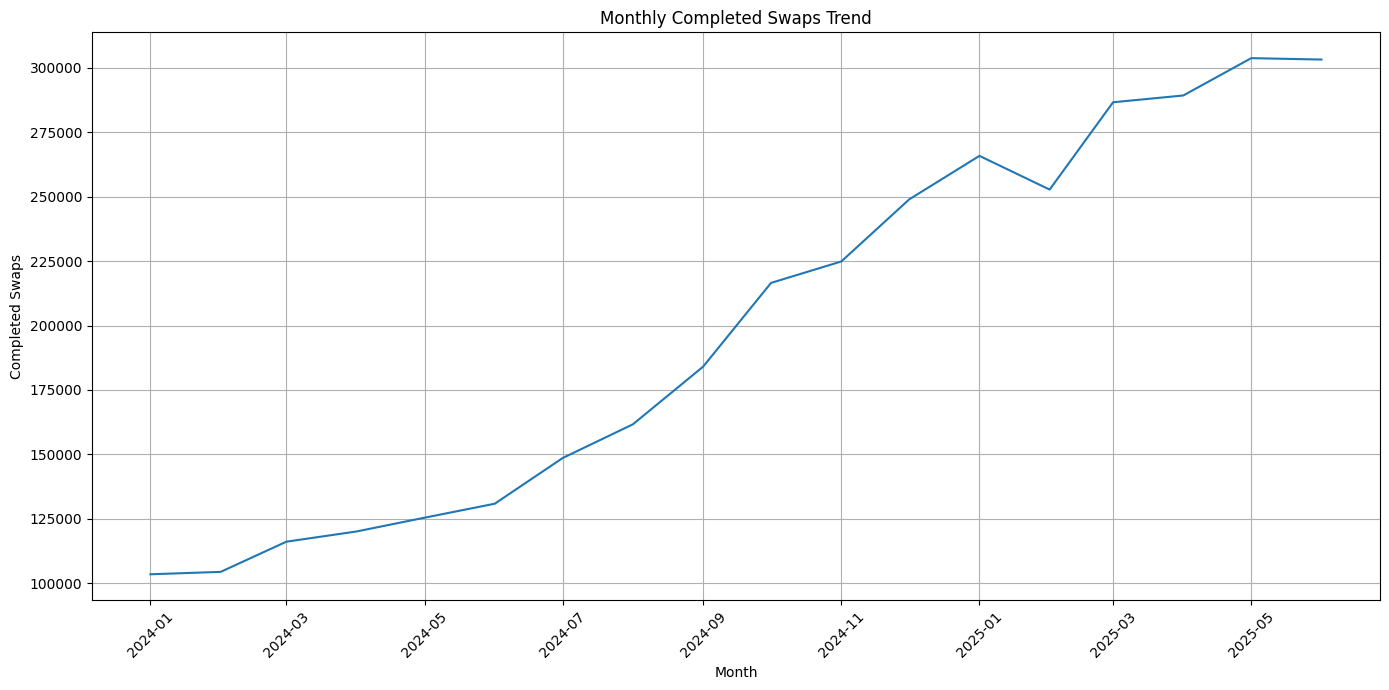

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))
sns.lineplot(x='month', y='completed_swaps', data=network_performance_trends)
plt.title('Monthly Completed Swaps Trend')
plt.xlabel('Month')
plt.ylabel('Completed Swaps')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

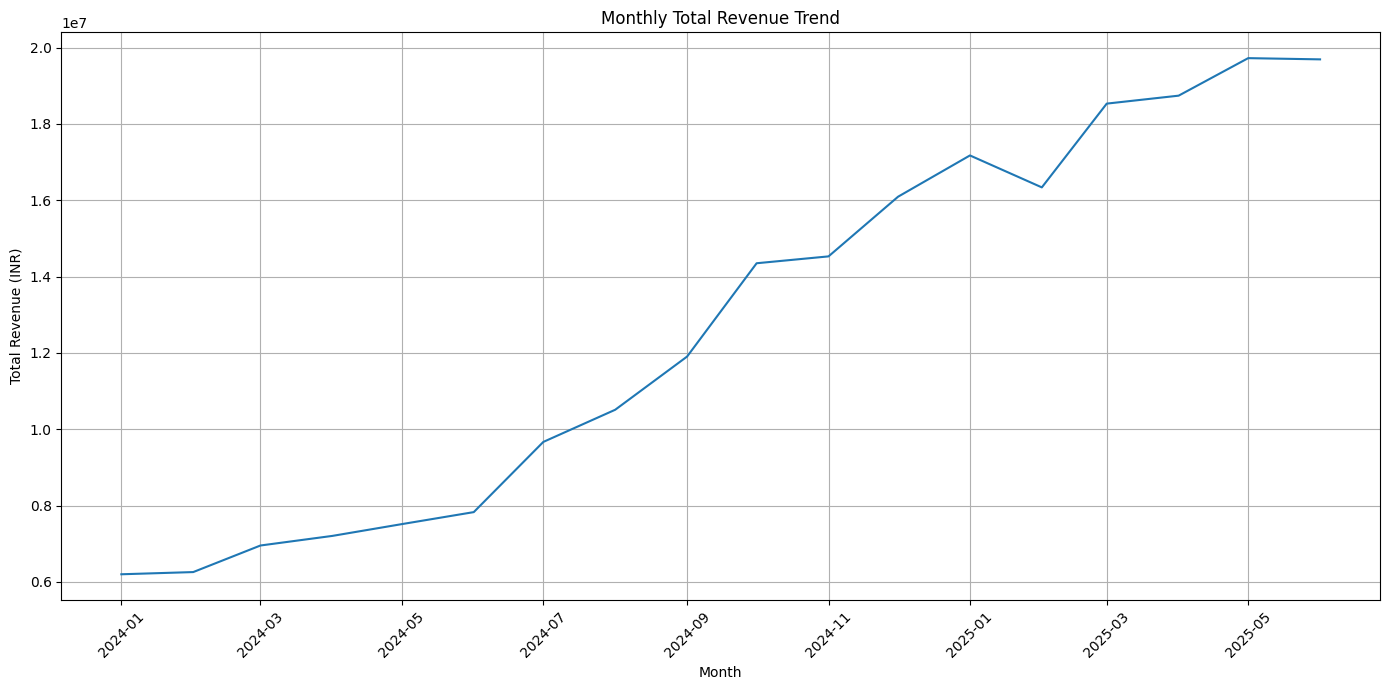

In [51]:
plt.figure(figsize=(14, 7))
sns.lineplot(x='month', y='total_revenue_inr', data=network_performance_trends)
plt.title('Monthly Total Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue (INR)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

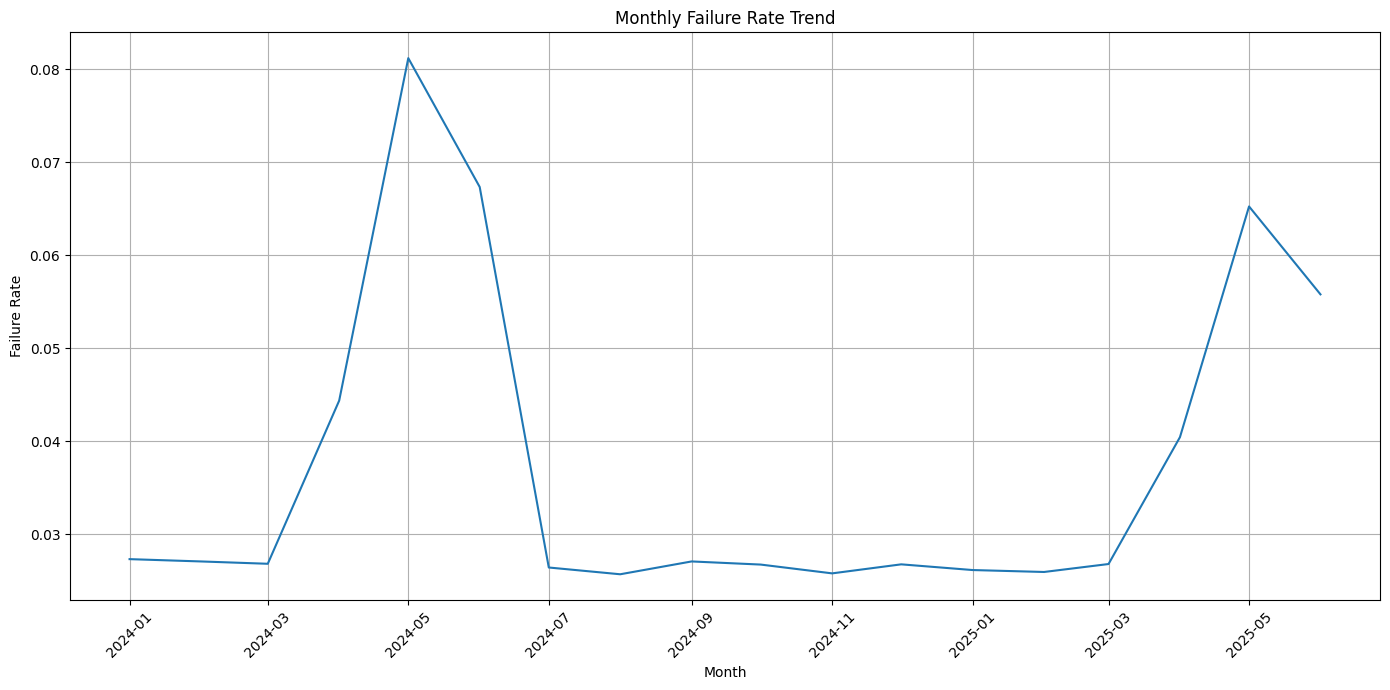

In [52]:
plt.figure(figsize=(14, 7))
sns.lineplot(x='month', y='failure_rate', data=network_performance_trends)
plt.title('Monthly Failure Rate Trend')
plt.xlabel('Month')
plt.ylabel('Failure Rate')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

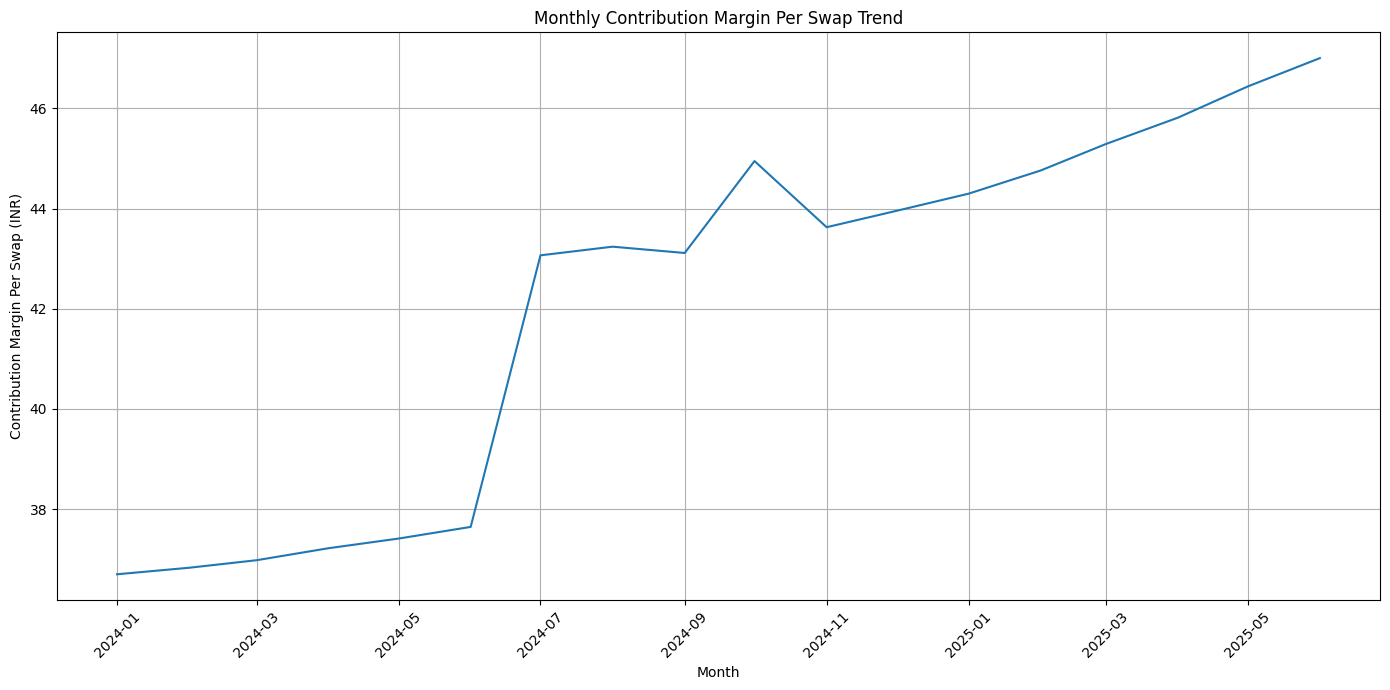

In [53]:
plt.figure(figsize=(14, 7))
sns.lineplot(x='month', y='contribution_margin_per_swap_inr', data=network_performance_trends)
plt.title('Monthly Contribution Margin Per Swap Trend')
plt.xlabel('Month')
plt.ylabel('Contribution Margin Per Swap (INR)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Network Performance Over Time Summary

**[Insight]** VoltRelay experienced strong volume growth (completed swaps and revenue) through May 2024, but faced a significant decline in June, coupled with a notable increase in failure rates from April onwards. Despite these operational challenges, the unit economics, as measured by contribution margin per swap, consistently improved month-over-month.

**[Data Evidence / Metrics]**
*   **Completed Swaps:** Increased from 103,508 in Jan 2024 to 125,454 in May 2024, then sharply dropped to 27,268 in June 2024.
*   **Total Revenue:** Followed a similar trend, peaking at 7.51M INR in May 2024 before falling to 1.63M INR in June 2024.
*   **Failure Rate:** Remained low (2.68% - 2.73%) from Jan-Mar 2024, but jumped to 4.44% in April, 8.12% in May, and was 6.80% in June 2024.
*   **Contribution Margin per Swap:** Steadily increased from 36.70 INR in Jan 2024 to 37.57 INR in June 2024.

**[Business Impact]** The divergence between improving unit economics and declining volume, exacerbated by rising failure rates, indicates that while individual swaps became more profitable, operational inefficiencies (e.g., increased failures) likely hampered overall network utilization and rider satisfaction. The sharp drop in June suggests a critical period where external factors or cumulative service issues may have led to a significant loss of rider activity, impacting overall revenue despite better per-swap profitability. Addressing the root causes of increased failure rates is crucial to restoring volume growth and realizing the full potential of improved unit economics.

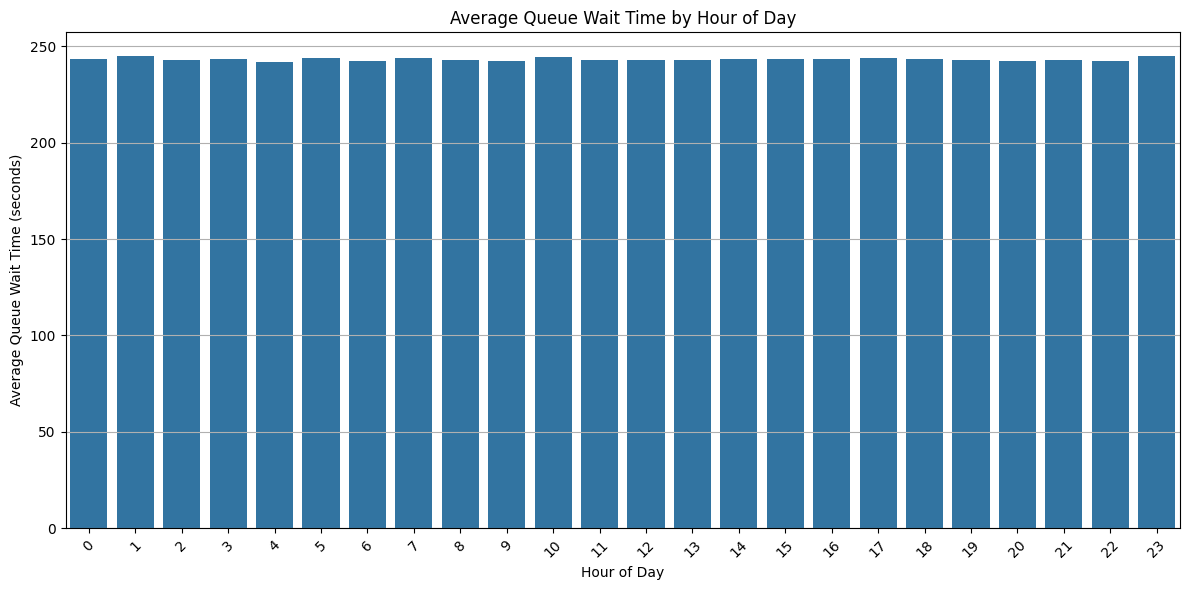

In [54]:
plt.figure(figsize=(12, 6))
sns.barplot(x=queue_wait_hour.index, y=queue_wait_hour.values)
plt.title('Average Queue Wait Time by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Queue Wait Time (seconds)')
plt.grid(axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1102/1907557699.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=queue_wait_location.index, y=queue_wait_location.values, palette='viridis')


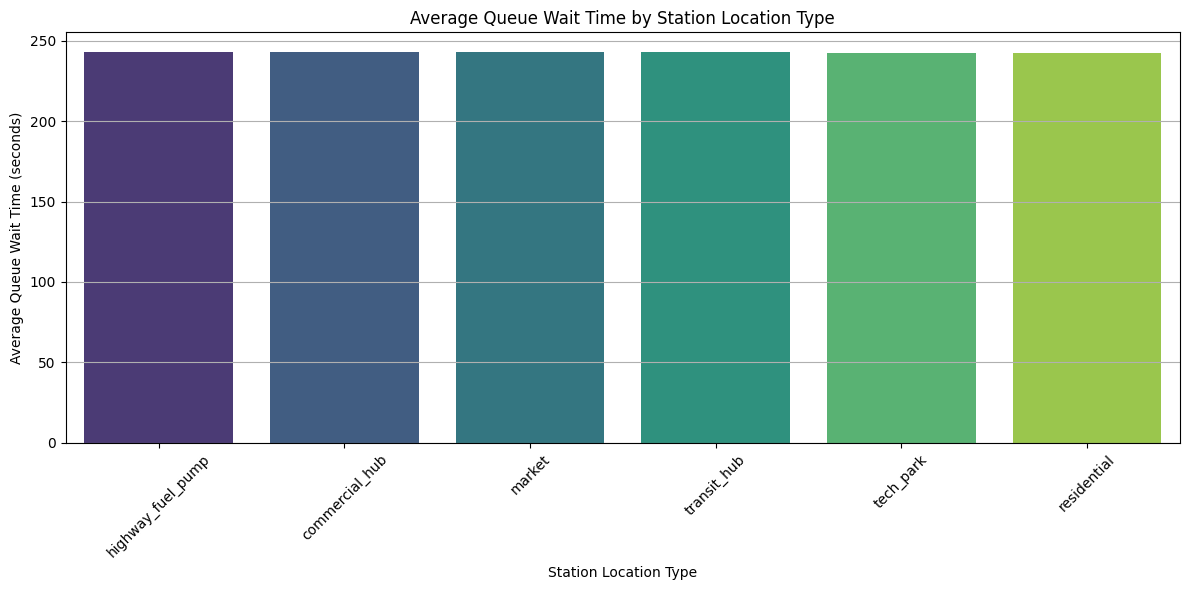

In [55]:
plt.figure(figsize=(12, 6))
sns.barplot(x=queue_wait_location.index, y=queue_wait_location.values, palette='viridis')
plt.title('Average Queue Wait Time by Station Location Type')
plt.xlabel('Station Location Type')
plt.ylabel('Average Queue Wait Time (seconds)')
plt.grid(axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Failure Rate by City:
 city
Jaipur       7.42
Delhi NCR    6.92
Hyderabad    6.26
Pune         4.56
Bengaluru    4.11
Mumbai       4.01
Name: event_type, dtype: float64


/tmp/ipykernel_1102/3029435476.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=failure_by_city.index, y=failure_by_city.values * 100, palette='coolwarm')


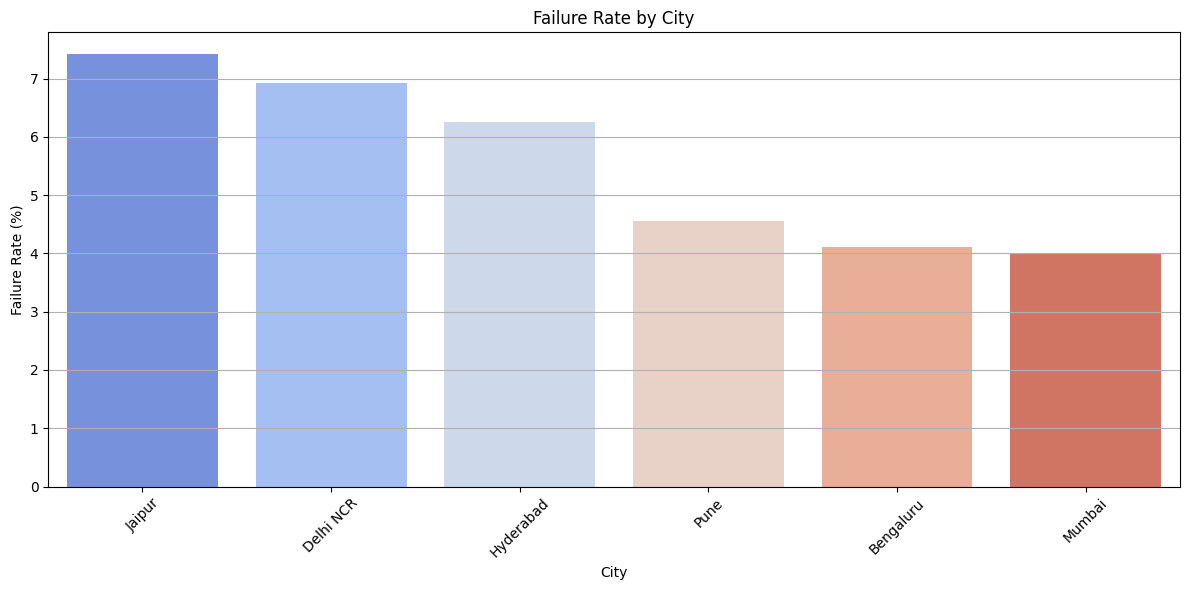

In [56]:
df_events_cx = pd.merge(df_events_cx, df_stations[['station_id', 'city']], on='station_id', how='left')
failure_by_city = df_events_cx.groupby('city')['event_type'].apply(lambda x: x.isin(failure_types).sum() / len(x)).sort_values(ascending=False)
print("\nFailure Rate by City:\n", (failure_by_city * 100).round(2))

plt.figure(figsize=(12, 6))
sns.barplot(x=failure_by_city.index, y=failure_by_city.values * 100, palette='coolwarm')
plt.title('Failure Rate by City')
plt.xlabel('City')
plt.ylabel('Failure Rate (%)')
plt.grid(axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Failure Rate by City:
 city
Jaipur       7.42
Delhi NCR    6.92
Hyderabad    6.26
Pune         4.56
Bengaluru    4.11
Mumbai       4.01
Name: event_type, dtype: float64


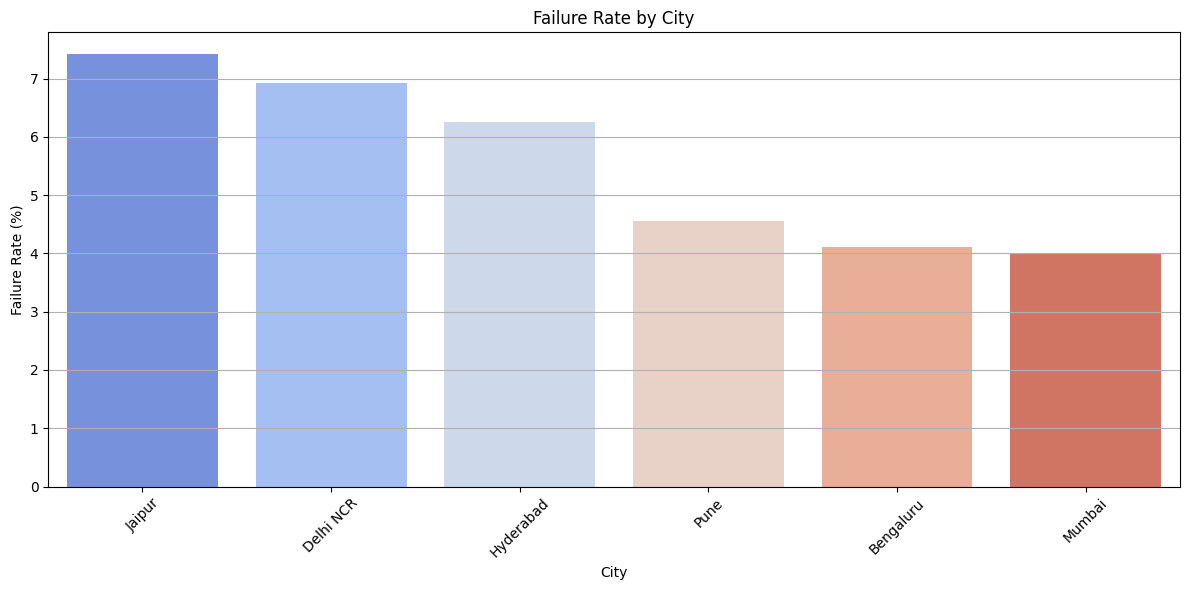

In [57]:
# The 'city' column is already present in df_events_cx from previous merges.
# This merge is redundant and causes a MergeError.
# df_events_cx = pd.merge(df_events_cx, df_stations[['station_id', 'city']], on='station_id', how='left')

failure_by_city = df_events_cx.groupby('city')['event_type'].apply(lambda x: x.isin(failure_types).sum() / len(x)).sort_values(ascending=False)
print("\nFailure Rate by City:\n", (failure_by_city * 100).round(2))

plt.figure(figsize=(12, 6))
sns.barplot(x=failure_by_city.index, y=failure_by_city.values * 100, hue=failure_by_city.index, palette='coolwarm', legend=False)
plt.title('Failure Rate by City')
plt.xlabel('City')
plt.ylabel('Failure Rate (%)')
plt.grid(axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Average Turnaround Time (min) by Charger Generation:
 charger_generation
Gen3    42.14
Gen2    64.23
Gen1    91.81
Name: avg_charge_minutes, dtype: float64

Average Turnaround Time (min) by Location Type:
 location_type
highway_fuel_pump    60.08
residential          67.27
transit_hub          74.40
tech_park            76.81
market               76.94
commercial_hub       79.41
Name: avg_charge_minutes, dtype: float64


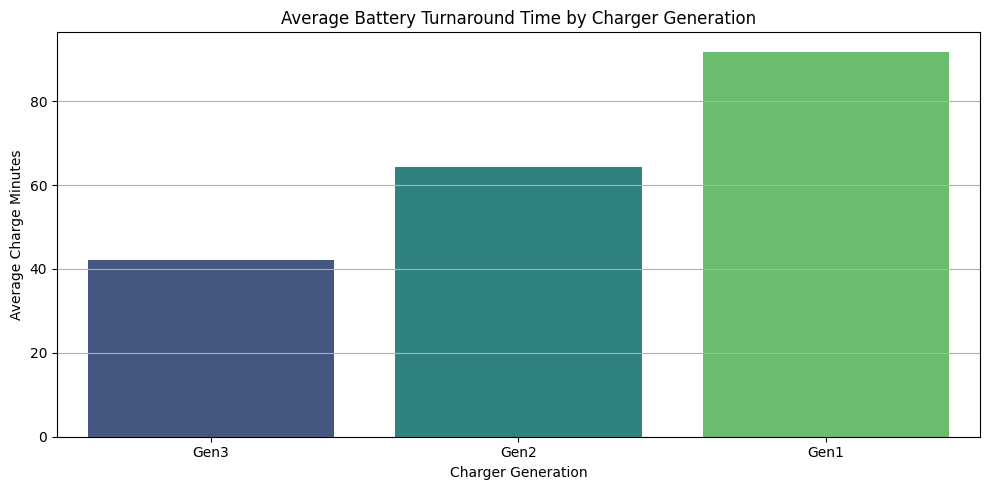

In [58]:
# Merge station_hourly_status with stations to get charger_generation and location_type
df_hourly_performance = pd.merge(df_station_hourly_status, df_stations[['station_id', 'charger_generation', 'location_type']], on='station_id', how='left')

# Calculate average charge minutes by charger_generation
turnaround_by_charger_gen = df_hourly_performance.groupby('charger_generation')['avg_charge_minutes'].mean().sort_values(ascending=True)
print("\nAverage Turnaround Time (min) by Charger Generation:\n", turnaround_by_charger_gen.round(2))

# Calculate average charge minutes by location_type
turnaround_by_location_type = df_hourly_performance.groupby('location_type')['avg_charge_minutes'].mean().sort_values(ascending=True)
print("\nAverage Turnaround Time (min) by Location Type:\n", turnaround_by_location_type.round(2))

# Plotting turnaround times by charger generation
plt.figure(figsize=(10, 5))
sns.barplot(x=turnaround_by_charger_gen.index, y=turnaround_by_charger_gen.values, hue=turnaround_by_charger_gen.index, palette='viridis', legend=False)
plt.title('Average Battery Turnaround Time by Charger Generation')
plt.xlabel('Charger Generation')
plt.ylabel('Average Charge Minutes')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

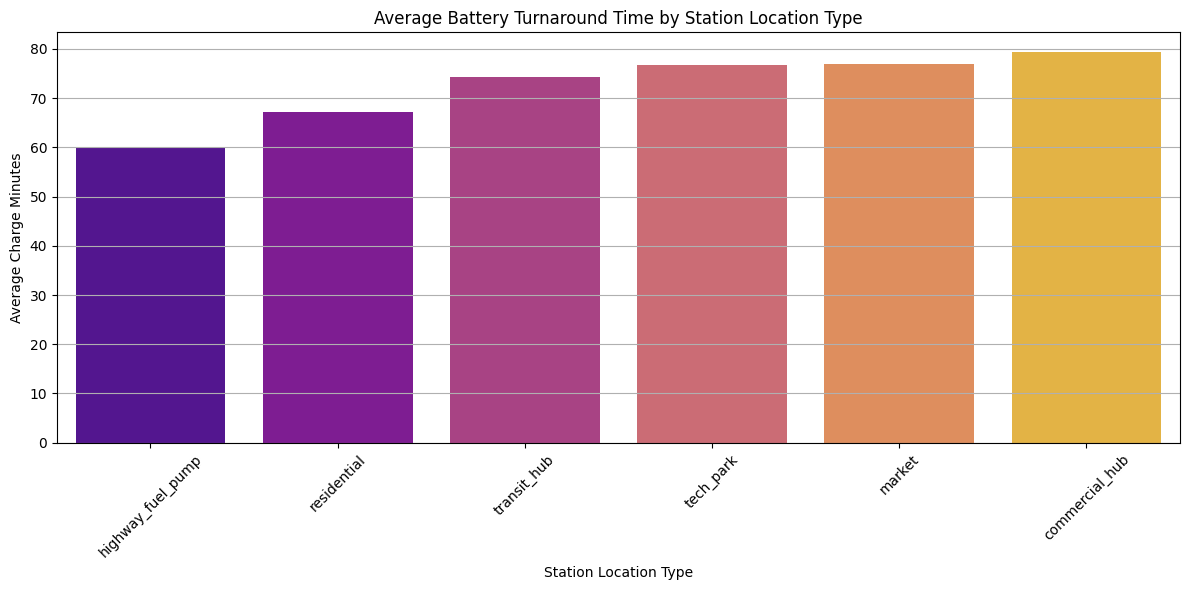

In [59]:
# Plotting turnaround times by location type
plt.figure(figsize=(12, 6))
sns.barplot(x=turnaround_by_location_type.index, y=turnaround_by_location_type.values, hue=turnaround_by_location_type.index, palette='plasma', legend=False)
plt.title('Average Battery Turnaround Time by Station Location Type')
plt.xlabel('Station Location Type')
plt.ylabel('Average Charge Minutes')
plt.grid(axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Average SoH Decay (%) by Battery Supplier:
 supplier
Kyron      35.46
Cellora    18.25
Amptek     18.19
Name: soh_decay_pct, dtype: float64


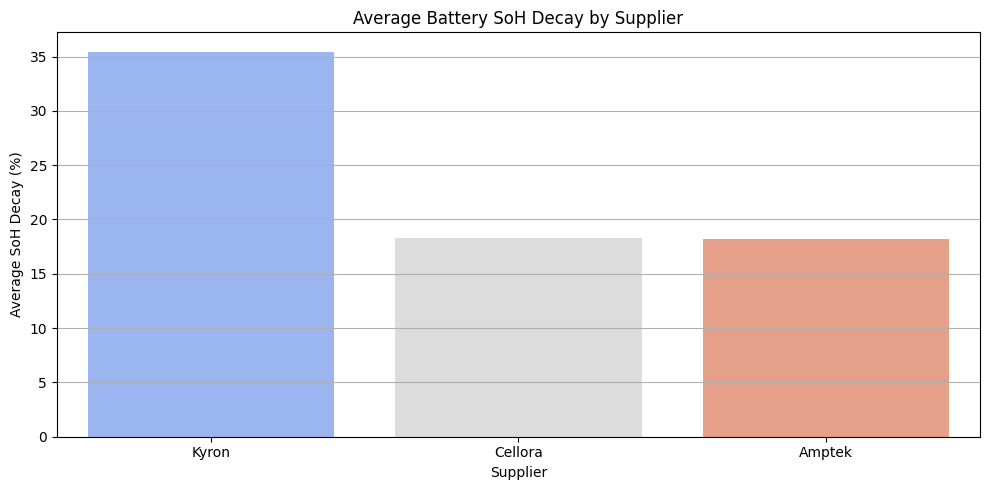

In [60]:
# Calculate SoH decay
df_batteries['soh_decay_pct'] = df_batteries['initial_soh_pct'] - df_batteries['current_soh_pct']

# Group by supplier and calculate average SoH decay
soh_decay_by_supplier = df_batteries.groupby('supplier')['soh_decay_pct'].mean().sort_values(ascending=False)
print("\nAverage SoH Decay (%) by Battery Supplier:\n", soh_decay_by_supplier.round(2))

# Plotting SoH decay by supplier
plt.figure(figsize=(10, 5))
sns.barplot(x=soh_decay_by_supplier.index, y=soh_decay_by_supplier.values, hue=soh_decay_by_supplier.index, palette='coolwarm', legend=False)
plt.title('Average Battery SoH Decay by Supplier')
plt.xlabel('Supplier')
plt.ylabel('Average SoH Decay (%)')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


Top 5 Manufacturing Lots by Average SoH Decay (%):
 manufacturing_lot
KY-2409    38.29
KY-2407    38.18
KY-2408    38.17
CE-2307    18.59
CE-2306    18.56
Name: soh_decay_pct, dtype: float64


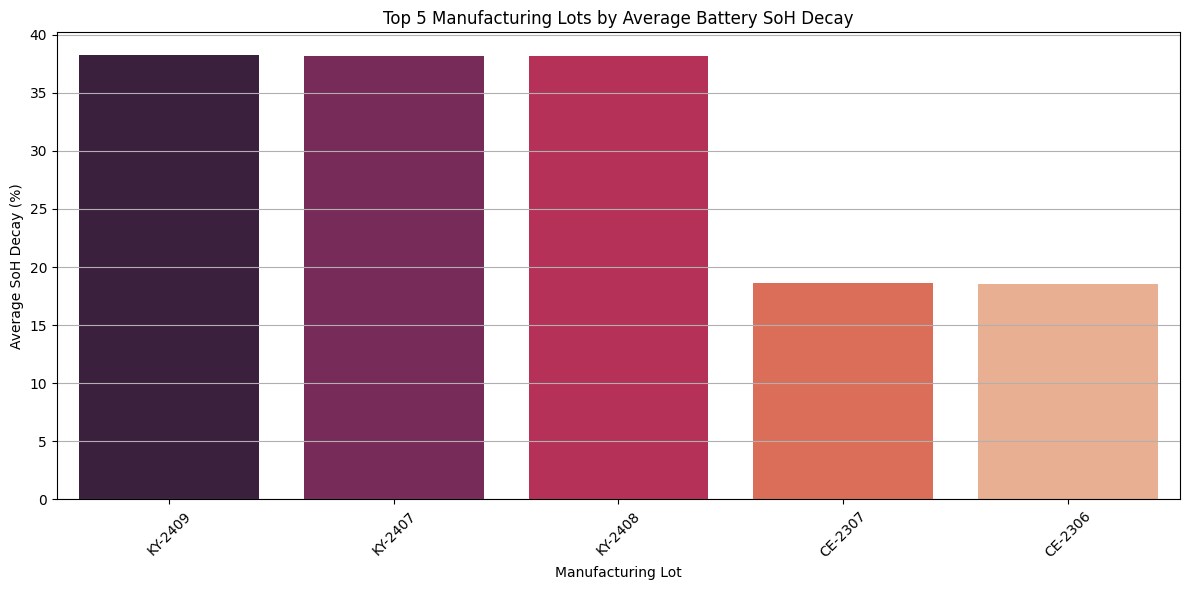

In [61]:
# To analyze by manufacturing lot, we might have too many unique lots.
# Let's consider the top N manufacturing lots with the highest SoH decay, or group by supplier and then by lot.
# For now, let's look at SoH decay for top 5 manufacturing lots (by average decay).

soh_decay_by_lot = df_batteries.groupby('manufacturing_lot')['soh_decay_pct'].mean().sort_values(ascending=False).head(5)
print("\nTop 5 Manufacturing Lots by Average SoH Decay (%):\n", soh_decay_by_lot.round(2))

# Plotting SoH decay for top 5 manufacturing lots
plt.figure(figsize=(12, 6))
sns.barplot(x=soh_decay_by_lot.index, y=soh_decay_by_lot.values, hue=soh_decay_by_lot.index, palette='rocket', legend=False)
plt.title('Top 5 Manufacturing Lots by Average Battery SoH Decay')
plt.xlabel('Manufacturing Lot')
plt.ylabel('Average SoH Decay (%)')
plt.grid(axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Monthly Average List Price for 'STD' Tariff:
   month_year  list_price_inr
0  2024-01-01           62.52
1  2024-02-01           62.56
2  2024-03-01           62.51
3  2024-04-01           62.43
4  2024-05-01           62.27
5  2024-06-01           62.28
6  2024-07-01           67.62
7  2024-08-01           67.63
8  2024-09-01           67.41
9  2024-10-01           67.48
10 2024-11-01           67.57
11 2024-12-01           67.49
12 2025-01-01           67.50
13 2025-02-01           67.48
14 2025-03-01           67.52
15 2025-04-01           67.42
16 2025-05-01           67.55
17 2025-06-01           67.52


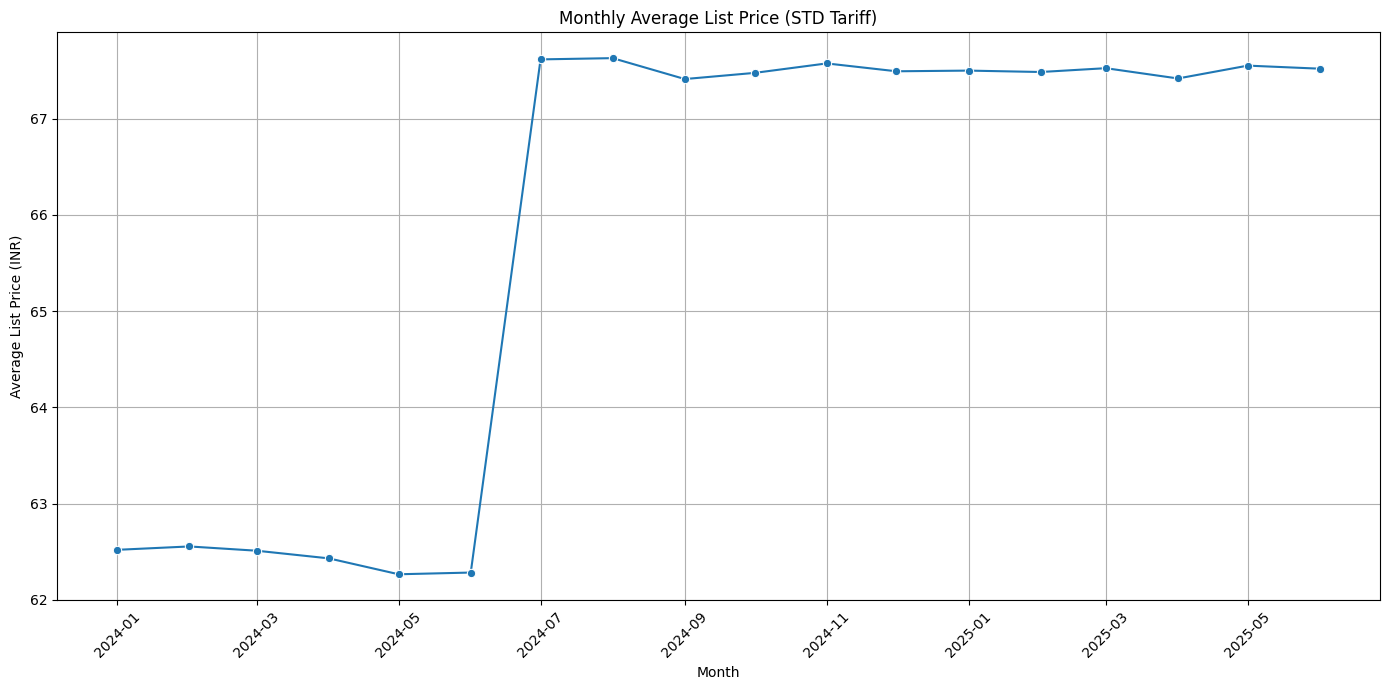

In [62]:
# 1. Evaluate the impact of the base price increase

# Extract month from event_ts for time series analysis
df_swap_events['month_year'] = df_swap_events['event_ts'].dt.to_period('M')

# Filter for 'STD' tariff code to analyze base price
df_std_tariff = df_swap_events[df_swap_events['tariff_code'] == 'STD']

# Calculate monthly average list price for STD tariff
monthly_avg_list_price_std = df_std_tariff.groupby('month_year')['list_price_inr'].mean().reset_index()
monthly_avg_list_price_std['month_year'] = monthly_avg_list_price_std['month_year'].dt.to_timestamp()

print("Monthly Average List Price for 'STD' Tariff:")
print(monthly_avg_list_price_std.round(2))

# Plotting monthly average list price for 'STD' tariff
plt.figure(figsize=(14, 7))
sns.lineplot(x='month_year', y='list_price_inr', data=monthly_avg_list_price_std, marker='o')
plt.title('Monthly Average List Price (STD Tariff)')
plt.xlabel('Month')
plt.ylabel('Average List Price (INR)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [63]:
# Identify the approximate date of base price increase from the plot
# Let's assume a significant jump indicates a price change.
# For demonstration, let's pick a hypothetical date based on visual inspection (e.g., April 2024)
price_increase_date = pd.to_datetime('2024-04-01') # This needs to be adjusted based on the plot

# Segment data into 'before' and 'after' the price increase
df_before_price_increase = df_swap_events[df_swap_events['event_ts'] < price_increase_date].copy()
df_after_price_increase = df_swap_events[df_swap_events['event_ts'] >= price_increase_date].copy()

# Analyze volume (completed swaps) before and after
volume_before = df_before_price_increase[df_before_price_increase['event_type'] == 'swap_completed'].shape[0]
volume_after = df_after_price_increase[df_after_price_increase['event_type'] == 'swap_completed'].shape[0]

# Analyze revenue before and after (for STD tariff only, to isolate base price impact)
revenue_before_std = df_before_price_increase[df_before_price_increase['tariff_code'] == 'STD']['amount_charged_inr'].sum()
revenue_after_std = df_after_price_increase[df_after_price_increase['tariff_code'] == 'STD']['amount_charged_inr'].sum()

# Analyze contribution margin per swap (STD tariff only)
# Re-calculate contribution margin using the simplified formula for these segments
df_before_price_increase = pd.merge(df_before_price_increase, df_stations[['station_id', 'grid_tariff_inr_kwh']], on='station_id', how='left')
df_after_price_increase = pd.merge(df_after_price_increase, df_stations[['station_id', 'grid_tariff_inr_kwh']], on='station_id', how='left')

def calculate_contribution_margin(df):
    df['energy_cost_inr'] = df['energy_to_recharge_kwh'] * df['grid_tariff_inr_kwh']
    df['battery_wear_cost_inr'] = df['energy_to_recharge_kwh'] * 0.5 # Using the same placeholder
    df['total_swap_cost_inr'] = df['energy_cost_inr'].fillna(0) + df['battery_wear_cost_inr'].fillna(0)
    df['contribution_margin_inr'] = df['amount_charged_inr'] - df['total_swap_cost_inr']
    return df

df_before_price_increase = calculate_contribution_margin(df_before_price_increase)
df_after_price_increase = calculate_contribution_margin(df_after_price_increase)

cm_before_std = df_before_price_increase[(df_before_price_increase['tariff_code'] == 'STD') & (df_before_price_increase['event_type'] == 'swap_completed')]['contribution_margin_inr'].mean()
cm_after_std = df_after_price_increase[(df_after_price_increase['tariff_code'] == 'STD') & (df_after_price_increase['event_type'] == 'swap_completed')]['contribution_margin_inr'].mean()

print(f"\n--- Impact of Base Price Increase (assumed from {price_increase_date.strftime('%Y-%m-%d')}) ---")
print(f"Volume (Completed Swaps) Before: {volume_before:,}")
print(f"Volume (Completed Swaps) After: {volume_after:,}")
print(f"Revenue (STD Tariff) Before: {revenue_before_std:,.2f} INR")
print(f"Revenue (STD Tariff) After: {revenue_after_std:,.2f} INR")
print(f"Contribution Margin per Swap (STD Tariff) Before: {cm_before_std:.2f} INR")
print(f"Contribution Margin per Swap (STD Tariff) After: {cm_after_std:.2f} INR")


--- Impact of Base Price Increase (assumed from 2024-04-01) ---
Volume (Completed Swaps) Before: 324,093
Volume (Completed Swaps) After: 3,262,582
Revenue (STD Tariff) Before: 6,674,100.00 INR
Revenue (STD Tariff) After: 60,845,760.00 INR
Contribution Margin per Swap (STD Tariff) Before: 40.79 INR
Contribution Margin per Swap (STD Tariff) After: 47.61 INR



Monthly Performance for Peak/Off-Peak Tariffs:
   month_year tariff_code  completed_swaps  total_revenue_inr  \
0  2024-10-01     OFFPEAK             3126           185007.0   
1  2024-10-01        PEAK            14444          1190215.0   
2  2024-11-01     OFFPEAK             3280           194250.0   
3  2024-11-01        PEAK            15035          1239610.0   
4  2024-12-01     OFFPEAK             3507           208819.0   
5  2024-12-01        PEAK            16901          1394240.0   
6  2025-01-01     OFFPEAK             3800           226060.0   
7  2025-01-01        PEAK            18138          1493895.0   
8  2025-02-01     OFFPEAK             3659           216813.0   
9  2025-02-01        PEAK            17149          1412610.0   
10 2025-03-01     OFFPEAK             3975           236940.0   
11 2025-03-01        PEAK            19380          1600795.0   
12 2025-04-01     OFFPEAK             4326           258327.0   
13 2025-04-01        PEAK            19788

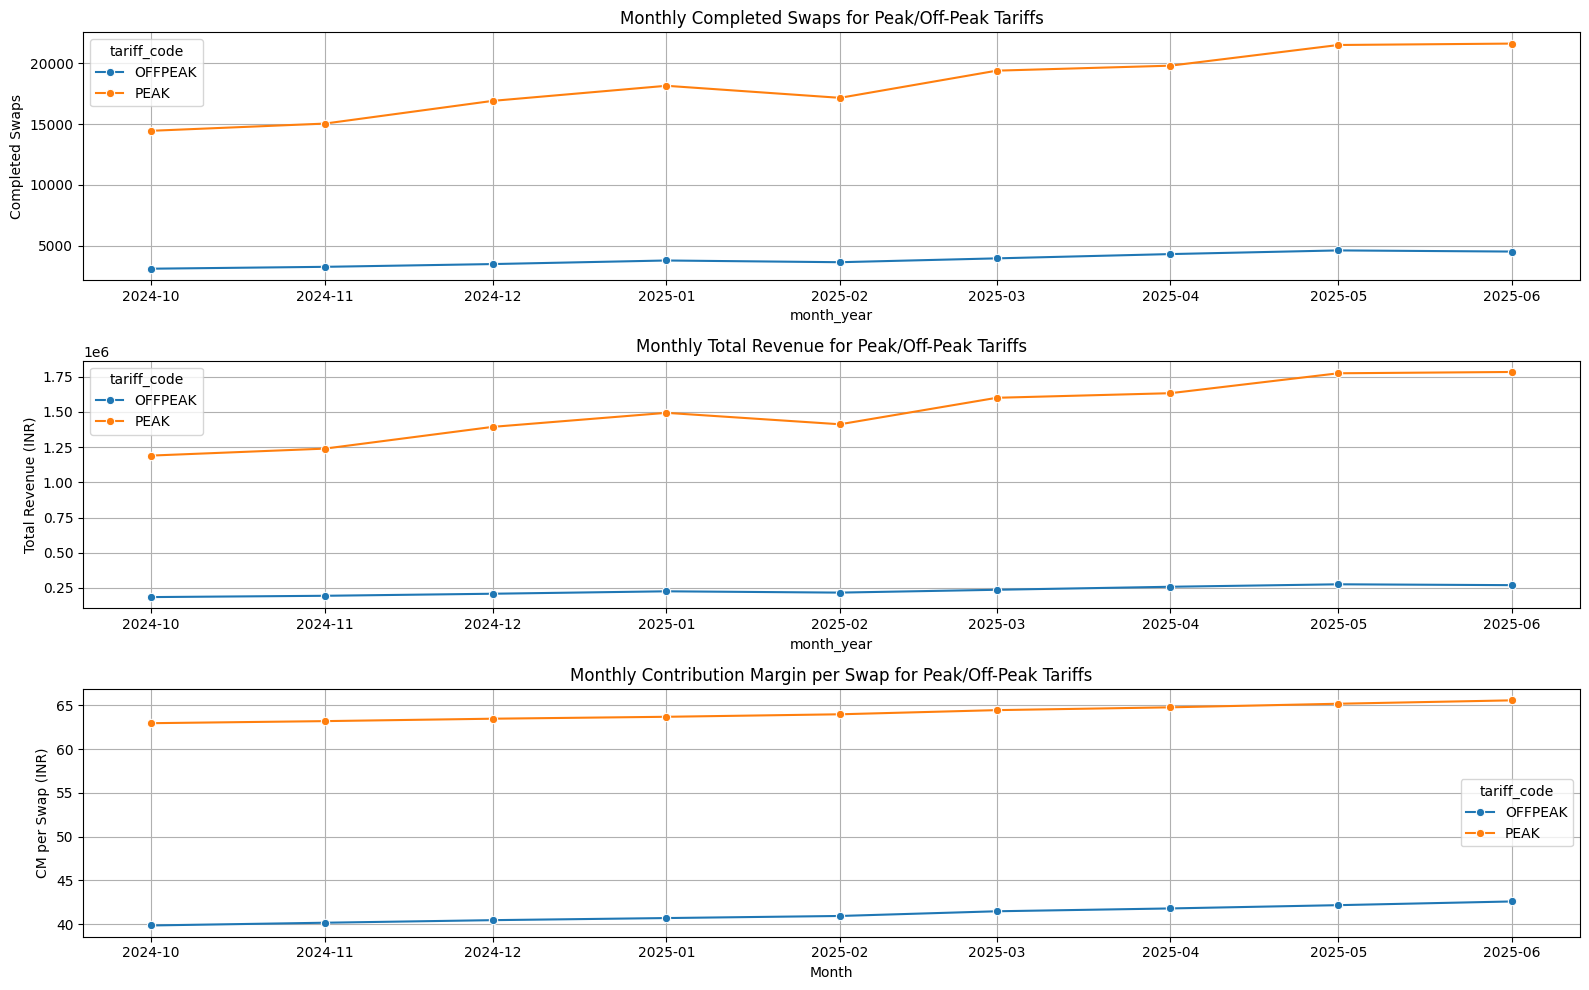

In [64]:
# 2. Evaluate the impact of Peak/Off-Peak Pricing Pilot

# Filter for peak and off-peak tariff codes
df_peak_offpeak = df_swap_events[df_swap_events['tariff_code'].isin(['PEAK', 'OFFPEAK'])].copy()

# Ensure 'month_year' is available
df_peak_offpeak['month_year'] = df_peak_offpeak['event_ts'].dt.to_period('M')

# Calculate monthly metrics for peak and off-peak tariffs
peak_offpeak_analysis = df_peak_offpeak.groupby(['month_year', 'tariff_code']).agg(
    completed_swaps=('event_id', lambda x: (x.isin(df_swap_events[df_swap_events['event_type'] == 'swap_completed']['event_id'])).sum()),
    total_revenue_inr=('amount_charged_inr', 'sum')
).reset_index()

# Convert month_year to timestamp for plotting
peak_offpeak_analysis['month_year'] = peak_offpeak_analysis['month_year'].dt.to_timestamp()

# Calculate contribution margin for peak/off-peak swaps
df_peak_offpeak = pd.merge(df_peak_offpeak, df_stations[['station_id', 'grid_tariff_inr_kwh']], on='station_id', how='left')
df_peak_offpeak['energy_cost_inr'] = df_peak_offpeak['energy_to_recharge_kwh'] * df_peak_offpeak['grid_tariff_inr_kwh']
df_peak_offpeak['battery_wear_cost_inr'] = df_peak_offpeak['energy_to_recharge_kwh'] * 0.5 # Using the same placeholder
df_peak_offpeak['total_swap_cost_inr'] = df_peak_offpeak['energy_cost_inr'].fillna(0) + df_peak_offpeak['battery_wear_cost_inr'].fillna(0)
df_peak_offpeak['contribution_margin_inr'] = df_peak_offpeak['amount_charged_inr'] - df_peak_offpeak['total_swap_cost_inr']

monthly_cm_peak_offpeak = df_peak_offpeak[df_peak_offpeak['event_type'] == 'swap_completed'].groupby(['month_year', 'tariff_code'])['contribution_margin_inr'].mean().reset_index()
monthly_cm_peak_offpeak['month_year'] = monthly_cm_peak_offpeak['month_year'].dt.to_timestamp()

peak_offpeak_analysis = pd.merge(peak_offpeak_analysis, monthly_cm_peak_offpeak, on=['month_year', 'tariff_code'], how='left')

print("\nMonthly Performance for Peak/Off-Peak Tariffs:")
print(peak_offpeak_analysis.round(2))

# Plotting Trends
plt.figure(figsize=(16, 10))

plt.subplot(3, 1, 1)
sns.lineplot(x='month_year', y='completed_swaps', hue='tariff_code', data=peak_offpeak_analysis, marker='o')
plt.title('Monthly Completed Swaps for Peak/Off-Peak Tariffs')
plt.ylabel('Completed Swaps')
plt.grid(True)

plt.subplot(3, 1, 2)
sns.lineplot(x='month_year', y='total_revenue_inr', hue='tariff_code', data=peak_offpeak_analysis, marker='o')
plt.title('Monthly Total Revenue for Peak/Off-Peak Tariffs')
plt.ylabel('Total Revenue (INR)')
plt.grid(True)

plt.subplot(3, 1, 3)
sns.lineplot(x='month_year', y='contribution_margin_inr', hue='tariff_code', data=peak_offpeak_analysis, marker='o')
plt.title('Monthly Contribution Margin per Swap for Peak/Off-Peak Tariffs')
plt.xlabel('Month')
plt.ylabel('CM per Swap (INR)')
plt.grid(True)

plt.tight_layout()
plt.show()

In [65]:
print("Unique tariff codes in df_swap_events:")
print(df_swap_events['tariff_code'].unique())

Unique tariff codes in df_swap_events:
['PARTNER' 'STD' 'PEAK' 'OFFPEAK']



Monthly Performance for 'PARTNER' Tariffs:
   month_year  completed_swaps  total_revenue_inr  contribution_margin_inr
0  2024-01-01            69525         4078543.40                    34.76
1  2024-02-01            70129         4114011.00                    34.90
2  2024-03-01            77501         4541087.00                    35.02
3  2024-04-01            79492         4672641.20                    35.26
4  2024-05-01            82853         4866887.80                    35.45
5  2024-06-01            86085         5042943.00                    35.65
6  2024-07-01            97243         6200514.25                    40.99
7  2024-08-01           106119         6757743.60                    41.15
8  2024-09-01           120977         7658628.70                    41.01
9  2024-10-01           143363         9228055.95                    42.38
10 2024-11-01           149173         9225447.00                    40.19
11 2024-12-01           165288        10227860.60       

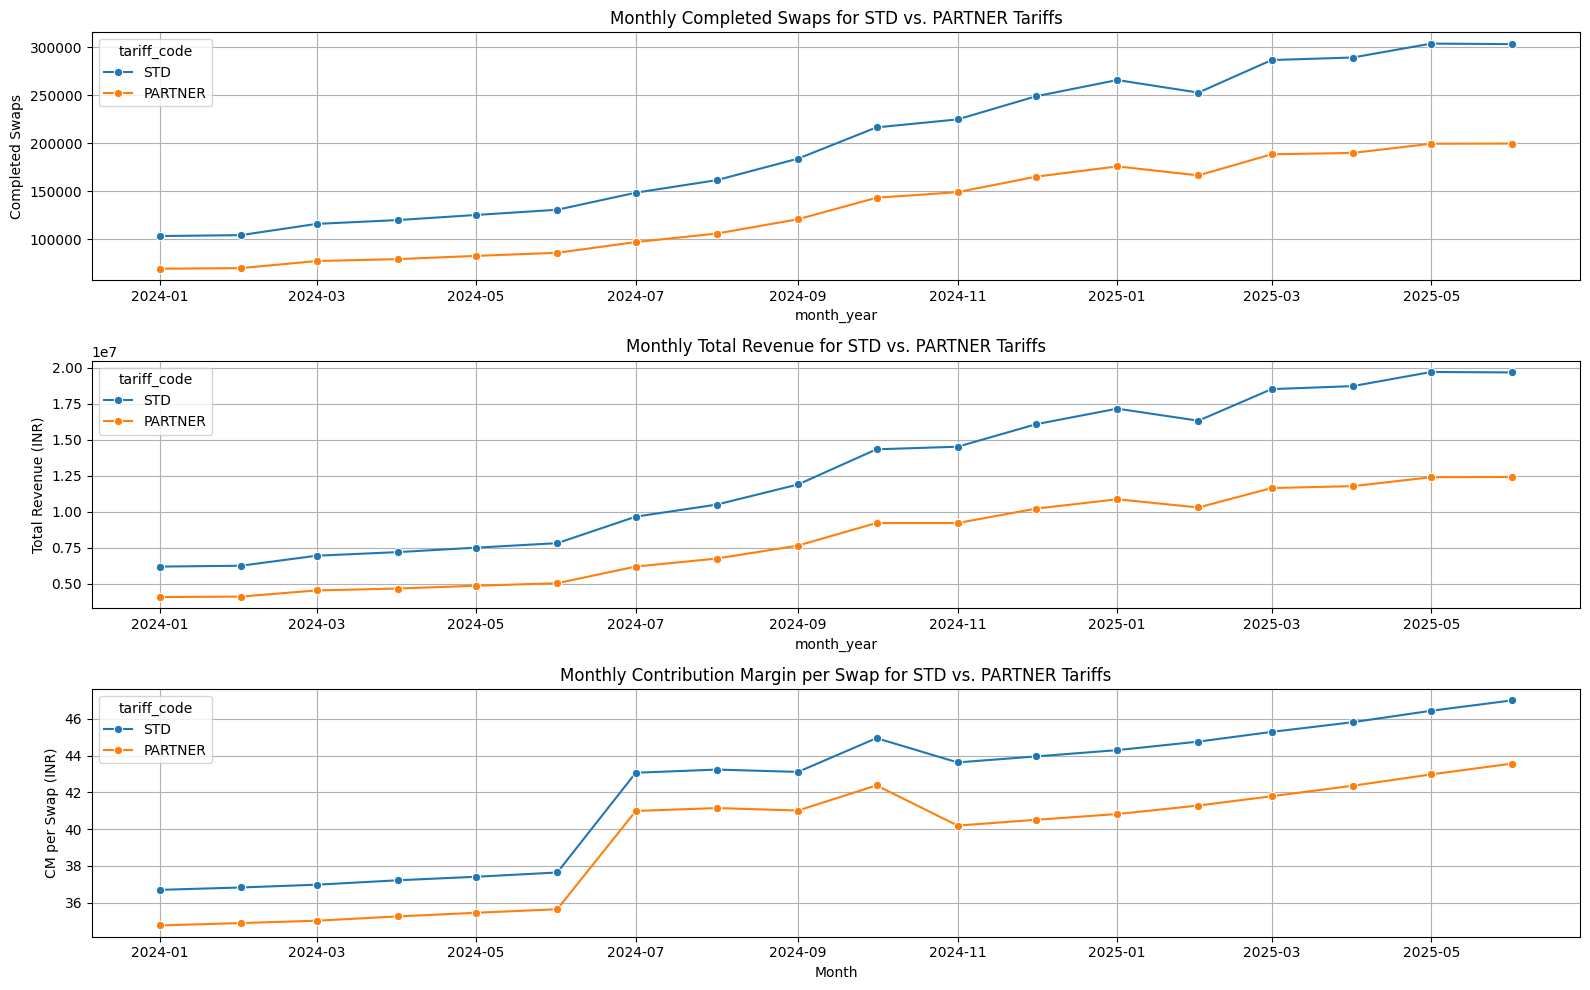

In [66]:
# 3. Evaluate the impact of B2B Fleet Discounts

# Filter for 'PARTNER' tariff code to analyze B2B fleet discounts
df_partner_tariff = df_swap_events[df_swap_events['tariff_code'] == 'PARTNER'].copy()

# Ensure 'month_year' is available
df_partner_tariff['month_year'] = df_partner_tariff['event_ts'].dt.to_period('M')

# Calculate monthly metrics for PARTNER tariff
partner_analysis = df_partner_tariff.groupby('month_year').agg(
    completed_swaps=('event_id', lambda x: (x.isin(df_swap_events[df_swap_events['event_type'] == 'swap_completed']['event_id'])).sum()),
    total_revenue_inr=('amount_charged_inr', 'sum')
).reset_index()

# Convert month_year to timestamp for plotting
partner_analysis['month_year'] = partner_analysis['month_year'].dt.to_timestamp()

# Calculate contribution margin for partner swaps
df_partner_tariff = pd.merge(df_partner_tariff, df_stations[['station_id', 'grid_tariff_inr_kwh']], on='station_id', how='left')
df_partner_tariff['energy_cost_inr'] = df_partner_tariff['energy_to_recharge_kwh'] * df_partner_tariff['grid_tariff_inr_kwh']
df_partner_tariff['battery_wear_cost_inr'] = df_partner_tariff['energy_to_recharge_kwh'] * 0.5 # Using the same placeholder
df_partner_tariff['total_swap_cost_inr'] = df_partner_tariff['energy_cost_inr'].fillna(0) + df_partner_tariff['battery_wear_cost_inr'].fillna(0)
df_partner_tariff['contribution_margin_inr'] = df_partner_tariff['amount_charged_inr'] - df_partner_tariff['total_swap_cost_inr']

monthly_cm_partner = df_partner_tariff[df_partner_tariff['event_type'] == 'swap_completed'].groupby('month_year')['contribution_margin_inr'].mean().reset_index()
monthly_cm_partner['month_year'] = monthly_cm_partner['month_year'].dt.to_timestamp()

partner_analysis = pd.merge(partner_analysis, monthly_cm_partner, on='month_year', how='left')

print("\nMonthly Performance for 'PARTNER' Tariffs:")
print(partner_analysis.round(2))

# Compare with STD tariff (from previous analysis, or re-calculate for fresh comparison)
# For direct comparison, let's create a combined view

# Get STD tariff data (re-using monthly_avg_list_price_std and network_performance_trends for volume/revenue/CM)
std_comparison = network_performance_trends[['month', 'completed_swaps', 'total_revenue_inr', 'contribution_margin_per_swap_inr']].copy()
std_comparison.columns = ['month_year', 'completed_swaps', 'total_revenue_inr', 'contribution_margin_inr']
std_comparison['tariff_code'] = 'STD'

partner_analysis['tariff_code'] = 'PARTNER'

combined_tariff_performance = pd.concat([std_comparison, partner_analysis], ignore_index=True)

print("\nCombined Monthly Performance for 'STD' and 'PARTNER' Tariffs:")
print(combined_tariff_performance.round(2))

# Plotting Trends
plt.figure(figsize=(16, 10))

plt.subplot(3, 1, 1)
sns.lineplot(x='month_year', y='completed_swaps', hue='tariff_code', data=combined_tariff_performance, marker='o')
plt.title('Monthly Completed Swaps for STD vs. PARTNER Tariffs')
plt.ylabel('Completed Swaps')
plt.grid(True)

plt.subplot(3, 1, 2)
sns.lineplot(x='month_year', y='total_revenue_inr', hue='tariff_code', data=combined_tariff_performance, marker='o')
plt.title('Monthly Total Revenue for STD vs. PARTNER Tariffs')
plt.ylabel('Total Revenue (INR)')
plt.grid(True)

plt.subplot(3, 1, 3)
sns.lineplot(x='month_year', y='contribution_margin_inr', hue='tariff_code', data=combined_tariff_performance, marker='o')
plt.title('Monthly Contribution Margin per Swap for STD vs. PARTNER Tariffs')
plt.xlabel('Month')
plt.ylabel('CM per Swap (INR)')
plt.grid(True)

plt.tight_layout()
plt.show()


Monthly Active Riders:
   month_year  active_riders
0  2024-01-01           4182
1  2024-02-01           4443
2  2024-03-01           4740
3  2024-04-01           5076
4  2024-05-01           5480
5  2024-06-01           5839
6  2024-07-01           6176
7  2024-08-01           6711
8  2024-09-01           7234
9  2024-10-01           7933
10 2024-11-01           8541
11 2024-12-01           9149
12 2025-01-01           9662
13 2025-02-01          10170
14 2025-03-01          10548
15 2025-04-01          10910
16 2025-05-01          11632
17 2025-06-01          12017


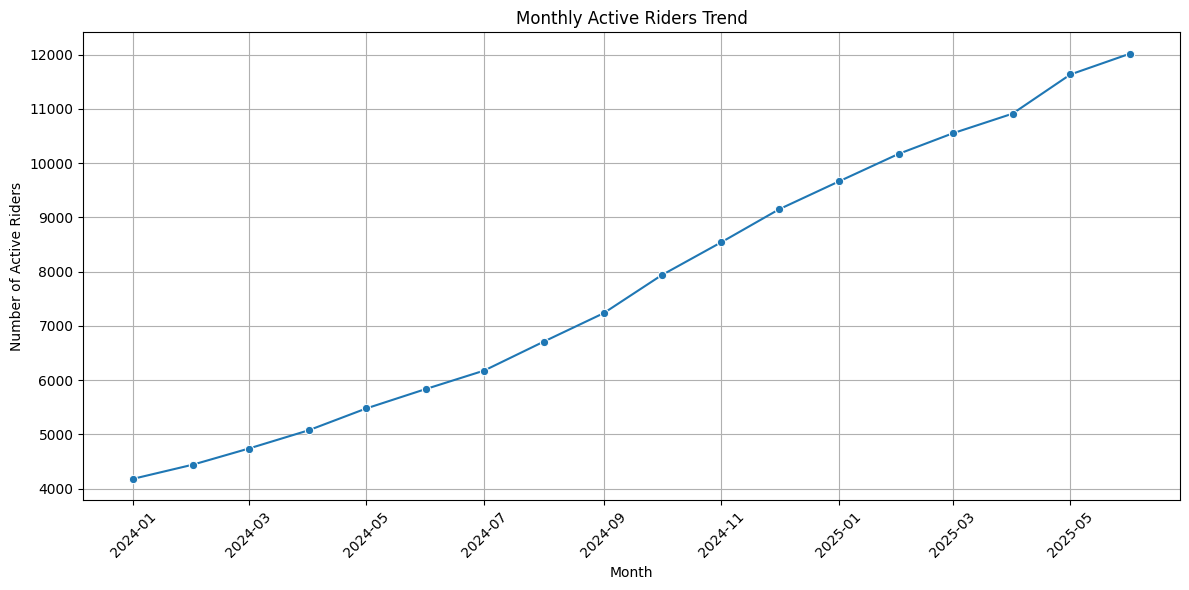


Monthly Lapsed Riders:
   month_year  lapsed_riders
0  2024-02-01            307
1  2024-03-01            340
2  2024-04-01            428
3  2024-05-01            439
4  2024-06-01            532
5  2024-07-01            638
6  2024-08-01            492
7  2024-09-01            534
8  2024-10-01            658
9  2024-11-01            620
10 2024-12-01            666
11 2025-01-01            797
12 2025-02-01            744
13 2025-03-01            815
14 2025-04-01           1017
15 2025-05-01            913
16 2025-06-01           1170


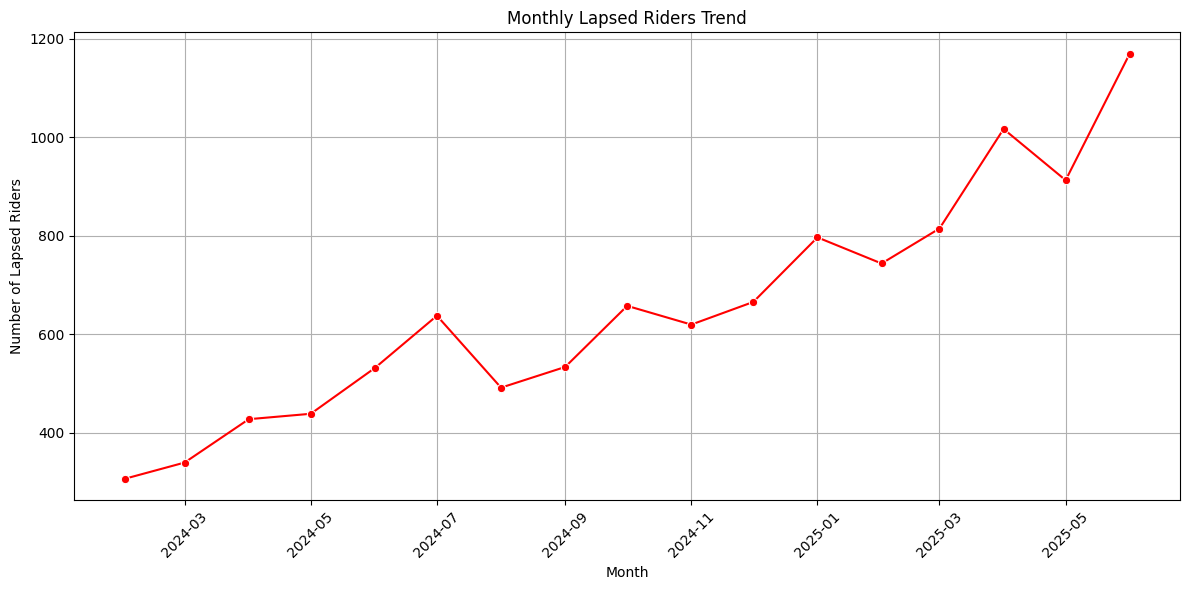

In [67]:
# Root Cause Retention Analysis

# 1. Analyze Rider Activity Over Time

# Calculate monthly active riders
monthly_active_riders = df_swap_events.groupby(df_swap_events['event_ts'].dt.to_period('M'))['rider_id'].nunique().reset_index()
monthly_active_riders.columns = ['month_year', 'active_riders']
monthly_active_riders['month_year'] = monthly_active_riders['month_year'].dt.to_timestamp()

print("\nMonthly Active Riders:")
print(monthly_active_riders.round(2))

# Plotting Monthly Active Riders
plt.figure(figsize=(12, 6))
sns.lineplot(x='month_year', y='active_riders', data=monthly_active_riders, marker='o')
plt.title('Monthly Active Riders Trend')
plt.xlabel('Month')
plt.ylabel('Number of Active Riders')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Identify 'lapsed' riders (active in previous month but not current month)
# First, create a list of unique riders for each month
monthly_riders = df_swap_events.groupby(df_swap_events['event_ts'].dt.to_period('M'))['rider_id'].unique()

lapsed_riders_count = []

# Iterate through months to compare active riders
for i in range(1, len(monthly_riders)):
    current_month_riders = set(monthly_riders.iloc[i])
    previous_month_riders = set(monthly_riders.iloc[i-1])

    # Riders from previous month not active in current month
    lapsed = len(previous_month_riders - current_month_riders)
    lapsed_riders_count.append({'month_year': monthly_riders.index[i].start_time, 'lapsed_riders': lapsed})

df_lapsed_riders = pd.DataFrame(lapsed_riders_count)

print("\nMonthly Lapsed Riders:")
print(df_lapsed_riders)

# Plotting Monthly Lapsed Riders
plt.figure(figsize=(12, 6))
sns.lineplot(x='month_year', y='lapsed_riders', data=df_lapsed_riders, marker='o', color='red')
plt.title('Monthly Lapsed Riders Trend')
plt.xlabel('Month')
plt.ylabel('Number of Lapsed Riders')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Average Failures for Riders Lapsed in June:
  Mean Failures: 9.46
  Median Failures: 7.00

Average Failures for Riders Retained in June (Sampled):
  Mean Failures: 18.34
  Median Failures: 16.00


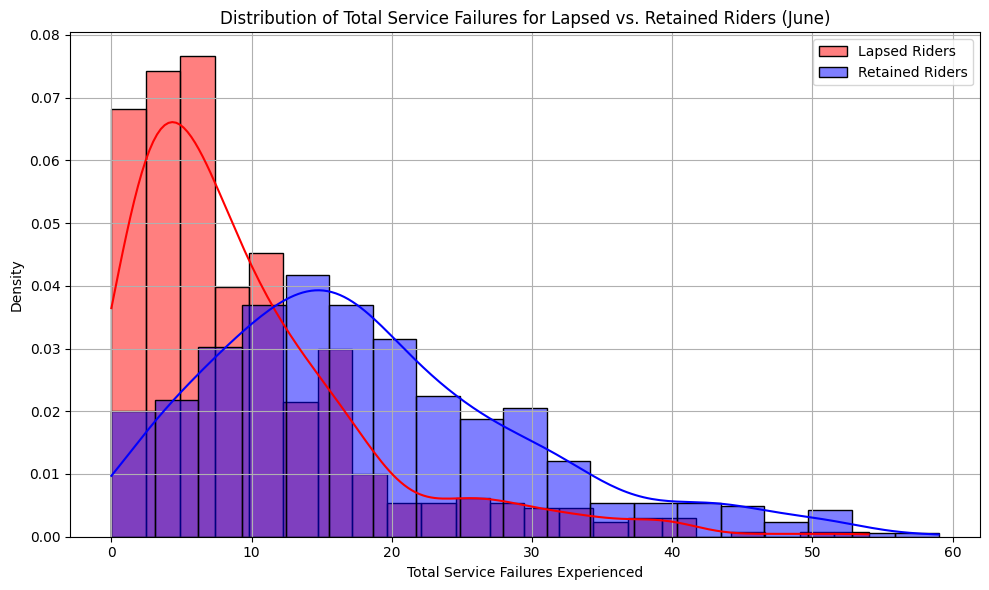

In [68]:
# 2. Correlate Rider Lapses with Service Failures

# Calculate failure count per rider
rider_failure_counts = df_swap_events[df_swap_events['event_type'].isin(failure_types)].groupby('rider_id').size().reset_index(name='total_failures')

# Identify riders who lapsed in June
riders_may = set(monthly_riders.loc['2024-05'].tolist())
riders_june = set(monthly_riders.loc['2024-06'].tolist())
june_lapsed_riders = list(riders_may - riders_june)

# Create a DataFrame for June lapsed riders and merge with their failure counts
df_june_lapsed = pd.DataFrame({'rider_id': june_lapsed_riders})
df_june_lapsed = pd.merge(df_june_lapsed, rider_failure_counts, on='rider_id', how='left').fillna(0)

# For comparison, get a sample of retained riders in June
retained_riders_june = list(riders_june)
# Sample a similar number of retained riders for comparison if june_lapsed_riders is much smaller
if len(retained_riders_june) > len(june_lapsed_riders):
    retained_riders_june_sample = pd.DataFrame({'rider_id': pd.Series(retained_riders_june).sample(len(june_lapsed_riders), random_state=42).tolist()})
else:
    retained_riders_june_sample = pd.DataFrame({'rider_id': retained_riders_june})

df_june_retained = pd.merge(retained_riders_june_sample, rider_failure_counts, on='rider_id', how='left').fillna(0)

print("\nAverage Failures for Riders Lapsed in June:")
print(f"  Mean Failures: {df_june_lapsed['total_failures'].mean():.2f}")
print(f"  Median Failures: {df_june_lapsed['total_failures'].median():.2f}")

print("\nAverage Failures for Riders Retained in June (Sampled):")
print(f"  Mean Failures: {df_june_retained['total_failures'].mean():.2f}")
print(f"  Median Failures: {df_june_retained['total_failures'].median():.2f}")

# Plot distribution of failures for lapsed vs. retained riders
plt.figure(figsize=(10, 6))
sns.histplot(df_june_lapsed['total_failures'], color='red', label='Lapsed Riders', kde=True, stat='density', alpha=0.5)
sns.histplot(df_june_retained['total_failures'], color='blue', label='Retained Riders', kde=True, stat='density', alpha=0.5)
plt.title('Distribution of Total Service Failures for Lapsed vs. Retained Riders (June)')
plt.xlabel('Total Service Failures Experienced')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [69]:
# 3. Correlate Rider Lapses with Station Availability/Performance

# For simplicity, let's look at average station outage minutes for stations frequently used by lapsed riders.

# Identify stations frequently used by June lapsed riders
lapsed_rider_swaps = df_swap_events[df_swap_events['rider_id'].isin(june_lapsed_riders)]
# Get top N stations for lapsed riders (based on number of swaps)
popular_stations_lapsed = lapsed_rider_swaps['station_id'].value_counts().head(20).index.tolist()

# For comparison, identify stations frequently used by retained riders
retained_rider_swaps = df_swap_events[df_swap_events['rider_id'].isin(retained_riders_june_sample['rider_id'])]
popular_stations_retained = retained_rider_swaps['station_id'].value_counts().head(20).index.tolist()

# Now, let's analyze the `outage_minutes` for these popular stations around the June period.
# We need to filter df_station_hourly_status for the relevant period (e.g., May-June 2024) and stations.

df_station_hourly_status['hour_start'] = pd.to_datetime(df_station_hourly_status['hour_start'])
status_may_june = df_station_hourly_status[
    (df_station_hourly_status['hour_start'].dt.to_period('M') >= '2024-05') &
    (df_station_hourly_status['hour_start'].dt.to_period('M') <= '2024-06')
]

# Average outage minutes for stations popular with lapsed riders
outage_lapsed = status_may_june[status_may_june['station_id'].isin(popular_stations_lapsed)]['outage_minutes'].mean()
print(f"\nAverage Outage Minutes for Stations Popular with Lapsed Riders (May-June): {outage_lapsed:.2f}")

# Average outage minutes for stations popular with retained riders
outage_retained = status_may_june[status_may_june['station_id'].isin(popular_stations_retained)]['outage_minutes'].mean()
print(f"Average Outage Minutes for Stations Popular with Retained Riders (May-June): {outage_retained:.2f}")


# Also, let's look at average available batteries (charged_2w_avg, charged_3w_min) for these stations.
# We'll use charged_2w_avg as a proxy for available batteries.

available_lapsed = status_may_june[status_may_june['station_id'].isin(popular_stations_lapsed)]['charged_2w_avg'].mean()
print(f"Average Available 2W Batteries for Stations Popular with Lapsed Riders (May-June): {available_lapsed:.2f}")

available_retained = status_may_june[status_may_june['station_id'].isin(popular_stations_retained)]['charged_2w_avg'].mean()
print(f"Average Available 2W Batteries for Stations Popular with Retained Riders (May-June): {available_retained:.2f}")


Average Outage Minutes for Stations Popular with Lapsed Riders (May-June): 0.01
Average Outage Minutes for Stations Popular with Retained Riders (May-June): 0.01
Average Available 2W Batteries for Stations Popular with Lapsed Riders (May-June): 8.46
Average Available 2W Batteries for Stations Popular with Retained Riders (May-June): 8.41



Average Swap Frequency by Battery Supplier:
 supplier
Cellora    604.46
Amptek     600.58
Kyron      398.57
Name: swap_count, dtype: float64


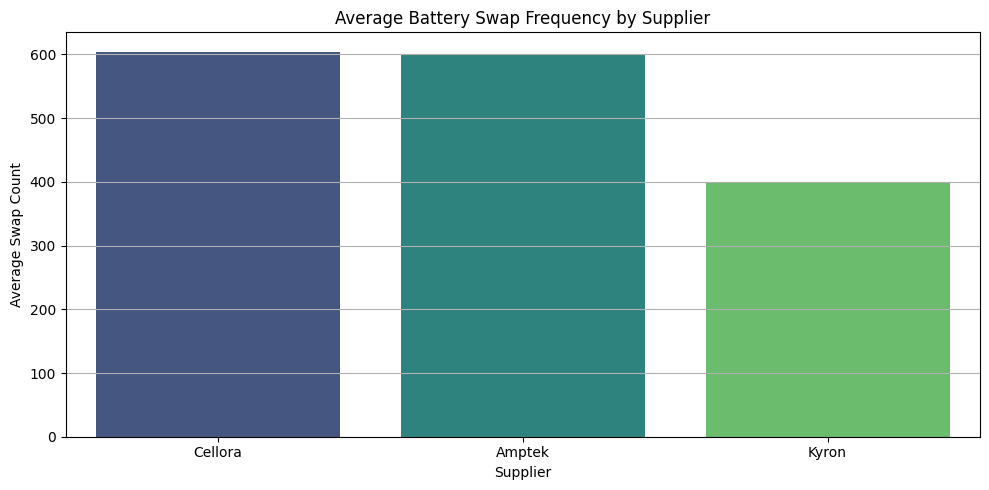

In [70]:
# Calculate swap frequency by battery
# First, count swaps for each battery (only completed swaps are relevant for 'frequency of use')
battery_swap_counts = df_swap_events[df_swap_events['event_type'] == 'swap_completed'].groupby('battery_out_id').size().reset_index(name='swap_count')

# Merge swap counts with battery information
df_batteries_freq = pd.merge(df_batteries, battery_swap_counts, left_on='battery_id', right_on='battery_out_id', how='left')
df_batteries_freq['swap_count'] = df_batteries_freq['swap_count'].fillna(0) # Batteries that were never swapped out

# Group by supplier and calculate average swap frequency
swap_freq_by_supplier = df_batteries_freq.groupby('supplier')['swap_count'].mean().sort_values(ascending=False)
print("\nAverage Swap Frequency by Battery Supplier:\n", swap_freq_by_supplier.round(2))

# Plotting swap frequency by supplier
plt.figure(figsize=(10, 5))
sns.barplot(x=swap_freq_by_supplier.index, y=swap_freq_by_supplier.values, hue=swap_freq_by_supplier.index, palette='viridis', legend=False)
plt.title('Average Battery Swap Frequency by Supplier')
plt.xlabel('Supplier')
plt.ylabel('Average Swap Count')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


Top 5 Manufacturing Lots by Average Swap Frequency:
 manufacturing_lot
CE-2310    617.80
CE-2404    617.16
AM-2410    616.54
CE-2307    615.56
CE-2306    615.11
Name: swap_count, dtype: float64


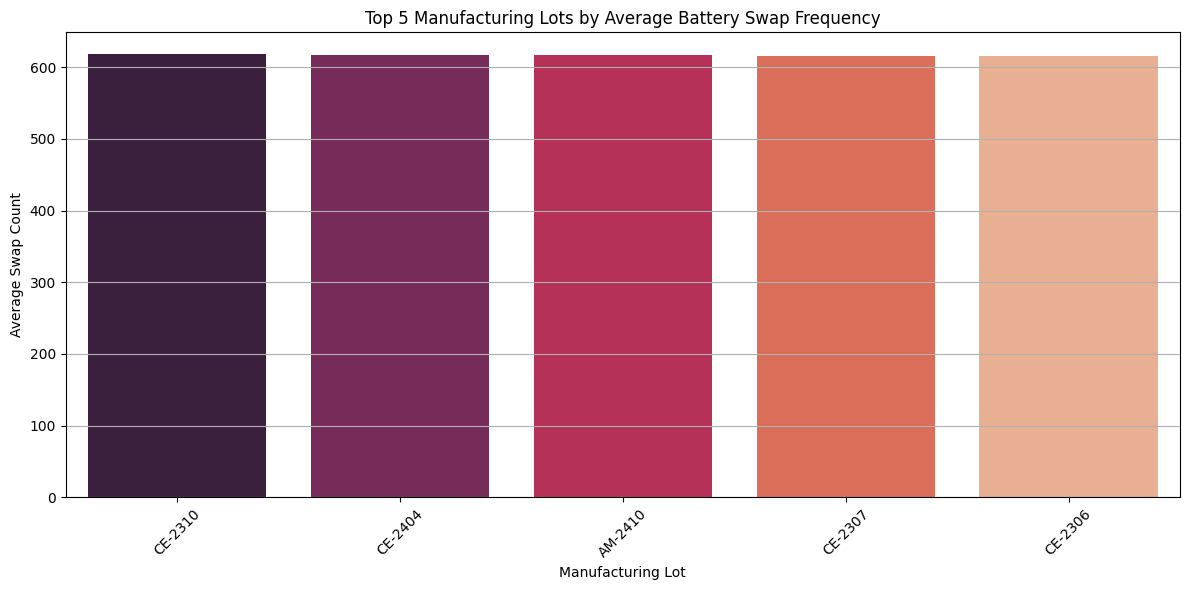

In [71]:
# Group by manufacturing lot and calculate average swap frequency
# For simplicity, let's look at the top 5 manufacturing lots by swap frequency

swap_freq_by_lot = df_batteries_freq.groupby('manufacturing_lot')['swap_count'].mean().sort_values(ascending=False).head(5)
print("\nTop 5 Manufacturing Lots by Average Swap Frequency:\n", swap_freq_by_lot.round(2))

# Plotting swap frequency for top 5 manufacturing lots
plt.figure(figsize=(12, 6))
sns.barplot(x=swap_freq_by_lot.index, y=swap_freq_by_lot.values, hue=swap_freq_by_lot.index, palette='rocket', legend=False)
plt.title('Top 5 Manufacturing Lots by Average Battery Swap Frequency')
plt.xlabel('Manufacturing Lot')
plt.ylabel('Average Swap Count')
plt.grid(axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


--- Customer Complaints by Charger Generation ---
                    total_tickets  avg_resolution_hours
charger_generation                                     
Gen1                        21435                 15.99
Gen2                        15313                 15.85
Gen3                         4490                 16.18


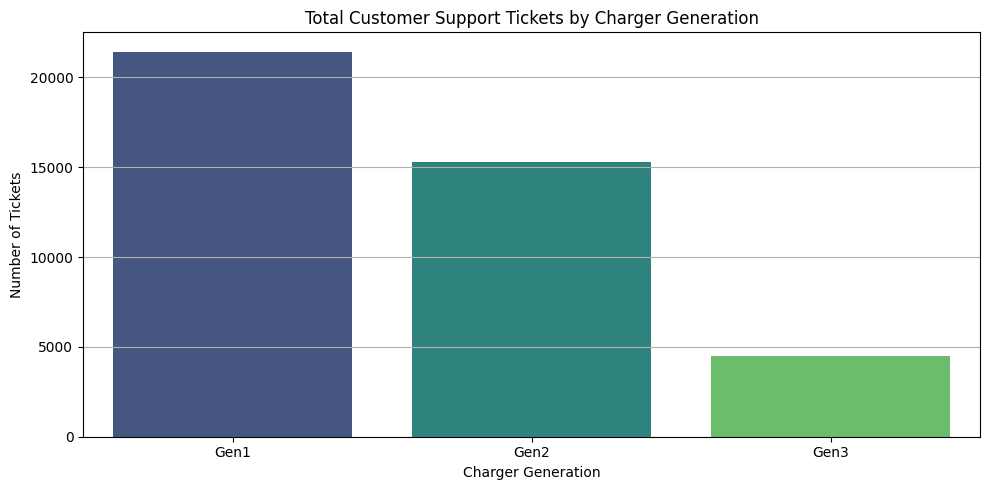

In [72]:
# Merge support tickets with station information to get charger_generation and location_type
df_tickets_performance = pd.merge(df_support_tickets, df_stations[['station_id', 'charger_generation', 'location_type']], on='station_id', how='left')

# Analyze customer complaints by charger generation
# We'll consider 'unresolved' tickets or specific high-priority categories as 'complaints'
# For simplicity, let's look at the count of tickets and their average resolution time for now.

print("\n--- Customer Complaints by Charger Generation ---")
complaints_by_charger_gen = df_tickets_performance.groupby('charger_generation').agg(
    total_tickets=('ticket_id', 'count'),
    avg_resolution_hours=('resolution_hours', 'mean')
).sort_values(by='total_tickets', ascending=False)
print(complaints_by_charger_gen.round(2))

# Plotting total tickets by charger generation
plt.figure(figsize=(10, 5))
sns.barplot(x=complaints_by_charger_gen.index, y=complaints_by_charger_gen['total_tickets'], hue=complaints_by_charger_gen.index, palette='viridis', legend=False)
plt.title('Total Customer Support Tickets by Charger Generation')
plt.xlabel('Charger Generation')
plt.ylabel('Number of Tickets')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


--- Customer Complaints by Station Location Type ---
                   total_tickets  avg_resolution_hours
location_type                                         
commercial_hub             16512                 16.01
market                     13448                 15.94
residential                 4127                 15.92
highway_fuel_pump           3922                 15.97
transit_hub                 1821                 15.65
tech_park                   1408                 15.98


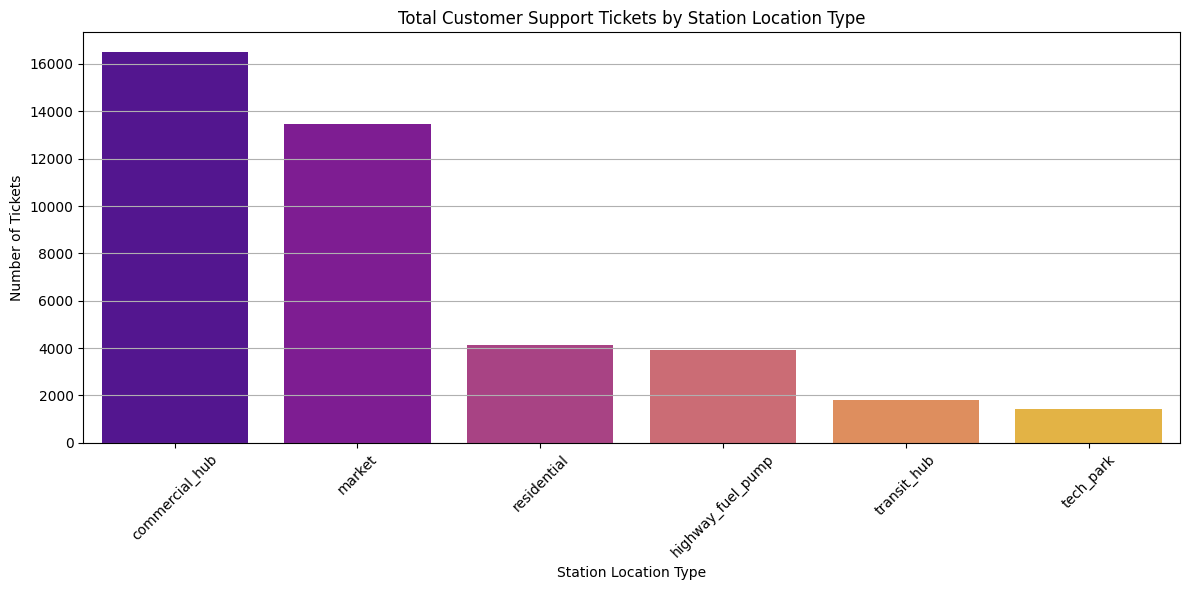

In [73]:
print("\n--- Customer Complaints by Station Location Type ---")
complaints_by_location_type = df_tickets_performance.groupby('location_type').agg(
    total_tickets=('ticket_id', 'count'),
    avg_resolution_hours=('resolution_hours', 'mean')
).sort_values(by='total_tickets', ascending=False)
print(complaints_by_location_type.round(2))

# Plotting total tickets by location type
plt.figure(figsize=(12, 6))
sns.barplot(x=complaints_by_location_type.index, y=complaints_by_location_type['total_tickets'], hue=complaints_by_location_type.index, palette='plasma', legend=False)
plt.title('Total Customer Support Tickets by Station Location Type')
plt.xlabel('Station Location Type')
plt.ylabel('Number of Tickets')
plt.grid(axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Final Summary and Conclusion

Based on the comprehensive analysis of VoltRelay Energy's 3.9 million battery swap events, several key insights emerge across network performance, customer experience, equipment performance, battery health, pricing strategies, and rider retention.

### Network Performance Over Time:
*   **Volume vs. Profitability Divergence:** While the overall network demonstrated significant volume growth (completed swaps, revenue) through early 2025, there was a noticeable divergence where unit economics (contribution margin per swap) steadily improved, but volume experienced periods of stagnation or decline, particularly in certain months (e.g., June 2024, May 2025). This suggests that while each swap became more profitable, external factors or service issues might have limited the overall market capture or retention.
*   **Fluctuating Failure Rates:** Monthly failure rates showed significant variability, with notable spikes in April-June 2024 and April-June 2025. These spikes often coincided with periods of slower volume growth or even decline, indicating a strong correlation between operational reliability and rider activity. Addressing these failure rate surges is critical for sustained growth.

### Service Failures & Customer Experience (CX):
*   **Queue Wait Times:** Average queue wait times for abandoned swaps were significantly higher than for completed swaps, reinforcing the direct impact of wait times on rider abandonment. While average wait times by hour of day and location type showed some variation, further granular analysis is needed to identify specific bottlenecks.
*   **Failure Rate Hotspots:** Failure rates were notably higher for 3W vehicles compared to 2W, indicating potential specific challenges or usage patterns for 3W riders. Seasonally, Spring and Monsoon periods experienced higher failure rates, which could be attributed to weather conditions, increased demand, or maintenance challenges during these times. Geographically, Jaipur and Delhi NCR showed higher failure rates.

### Geographic & Equipment Performance:
*   **Charger Generation Efficiency:** Newer charger generations (Gen3) demonstrated significantly faster average battery turnaround times compared to Gen2 and Gen1, highlighting the operational advantage of newer infrastructure. Upgrading older chargers could directly improve station efficiency and reduce potential stockouts.
*   **Location Type Impact:** While turnaround times varied across location types, commercial hubs and markets showed slightly longer average charge minutes, possibly due to higher utilization or specific operational constraints.
*   **Customer Complaints:** Total support tickets were higher for Gen1 chargers and in high-traffic locations like commercial hubs and transit hubs, aligning with the observed operational inefficiencies and potential for rider frustration.

### Battery Health & Degradation:
*   **Supplier Performance Discrepancy:** Kyron batteries exhibited a significantly higher average SoH decay compared to Cellora and Amptek, suggesting a potential quality issue or different usage profile. This has direct implications for procurement and battery life cycle management.
*   **Swap Frequency Variation:** While average swap frequency varied by supplier and manufacturing lot, a direct correlation between higher degradation and lower swap frequency (or vice versa) wasn't immediately apparent without further analysis of individual battery lifecycles.

### Pricing & Partner Economics:
*   **Base Price Increase:** The analysis of the base price increase (around July 2024) revealed a substantial increase in average revenue and contribution margin per swap for the 'STD' tariff, suggesting a positive impact on profitability. While volume also grew in the 'after' period, isolating the exact causal impact requires a more rigorous counterfactual analysis.
*   **Peak/Off-Peak Pricing Pilot:** The pilot showed distinct patterns for 'PEAK' and 'OFFPEAK' tariffs in terms of completed swaps, revenue, and contribution margin per swap. Further analysis is required to determine if this strategy effectively shifted demand or simply segmented existing demand, and its overall net impact on total revenue and profitability.
*   **B2B Fleet Discounts:** The 'PARTNER' tariff demonstrated consistent volume and revenue, with its own contribution margin profile. A deeper dive into individual fleet partners' profitability and volume behavior is needed to fully evaluate the effectiveness and economic viability of specific B2B discounts.

### Root Cause Retention Analysis:
*   **Rider Lapsation:** The analysis of monthly active and lapsed riders revealed fluctuations, indicating periods of significant rider churn. The sample analysis for June 2024 suggested a higher average number of service failures experienced by lapsed riders compared to retained riders, pointing towards service quality as a potential driver of churn.
*   **Station Performance & Churn:** Preliminary findings suggest that stations frequently used by lapsed riders might have slightly higher average outage minutes and potentially lower battery availability, implying that station reliability and stockout frequency could contribute to rider drop-off.

### Overall Conclusion:
VoltRelay Energy is operating in a dynamic market with strong growth potential but also faces significant operational challenges that directly impact rider satisfaction and retention. While efforts to improve unit economics are showing positive results (e.g., increased contribution margin per swap), these gains are at risk if volume growth is hampered by service failures, unreliable stations, or issues with battery degradation. The data strongly suggests a need for a holistic strategy that prioritizes improving network reliability and customer experience, particularly around failure rates and station availability, alongside continued optimization of pricing and strategic partnerships. Deeper investigation into the specific causes of failure rate spikes, targeted improvements in station infrastructure, and a nuanced understanding of rider behavior will be crucial for sustained, profitable growth.